# JWST Calibration Field
#### _This is a working notebook that I hope to keep organized and include all 4 datasets. I want to have subplots side by side._

In [2]:
#Package Installations
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

from astropy.io import fits
from astropy.visualization import simple_norm

from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground

from astropy.nddata.utils import Cutout2D
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

## Defining Functions
#### _This section is dedicated to initializing the field, uploading the proper files, visualizing them, and building functions._

In [3]:
f200w = fits.open('/Users/sshapiro/Desktop/200w DATA .fits')
f115w = fits.open('/Users/sshapiro/Desktop/115w DATA.fits')
f356w = fits.open('/Users/sshapiro/Desktop/jw01160-o022_f356w_gaia_pipeline_CLEAN_nlambad_521_V3_i2d.fits')
f444w = fits.open('/Users/sshapiro/Desktop/jw01160-o022_t011_nircam_clear-f444w_i2d.fits copy')

In [4]:
ims = [f115w, f200w, f356w, f444w]
titles = ["F115W", "F200W", "F356W", "F444W"]

In [5]:
def plot_original(title="Original Images"):
    
    norms = [simple_norm(im['SCI'].data, 'asinh', percent=99) for im in ims]

    fig, axs = plt.subplots(2, 2, figsize=(12, 12))
   

    for ax, im, norm, band in zip(axs.flat, ims, norms, titles):
        ax.imshow(im['SCI'].data, origin = 'lower', norm=norm, cmap='viridis')
        ax.set_title(band)

    plt.subplots_adjust(bottom=0.1, top=0.98)
    plt.suptitle(title, fontsize=14, fontweight='bold', y=.75)
    plt.tight_layout(h_pad=-25)
    plt.show()

### 2D Image Background Subtraction

In [6]:
sigma_clip = SigmaClip(sigma=5.6)
bkg_estimator = MedianBackground()
bkg_list =  [Background2D(im['SCI'].data, (200,200), filter_size=(3,3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator) for im in ims]

def plot_background (title="Background"):

    fig, axs = plt.subplots(2,2, figsize=(12,12))
    for ax, bkg, band in zip(axs.flat, bkg_list, titles):
        ax.imshow(bkg.background, origin='lower', interpolation='nearest')
        ax.set_title(band)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=.75)
    plt.tight_layout(h_pad=-25.0)
    plt.show()

In [7]:
im_subbk_list = [(im['SCI'].data-bkg.background) for im, bkg in zip(ims, bkg_list)]

def plot_imsubk(title = "Image with Background Subtraction"):
    
    norms = [simple_norm(im_subbk, 'asinh', percent=99.5) for im_subbk in im_subbk_list]

    fig, axs = plt.subplots(2,2, figsize=(12,12))
    for ax, im_subbk, norm, band in zip(axs.flat, im_subbk_list, norms, titles):
        ax.imshow(im_subbk, origin = 'lower', norm=norm, cmap='viridis')
        ax.set_title(band)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=.85)
    plt.tight_layout(h_pad=-25.0)
    plt.show()

### Image - Background

In [8]:
im_subbk_list = [(im['SCI'].data-bkg.background) for im, bkg in zip(ims, bkg_list)]

def plot_imsubk(title = "Image with Background Subtraction"):
    
    norms = [simple_norm(im_subbk, 'asinh', percent=99.5) for im_subbk in im_subbk_list]

    fig, axs = plt.subplots(2,2, figsize=(12,12))
    for ax, im_subbk, norm, band in zip(axs.flat, im_subbk_list, norms, titles):
        ax.imshow(im_subbk, origin = 'lower', norm=norm, cmap='viridis')
        ax.set_title(band)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=.85)
    plt.tight_layout(h_pad=-25.0)
    plt.show()

### All the Initial Images

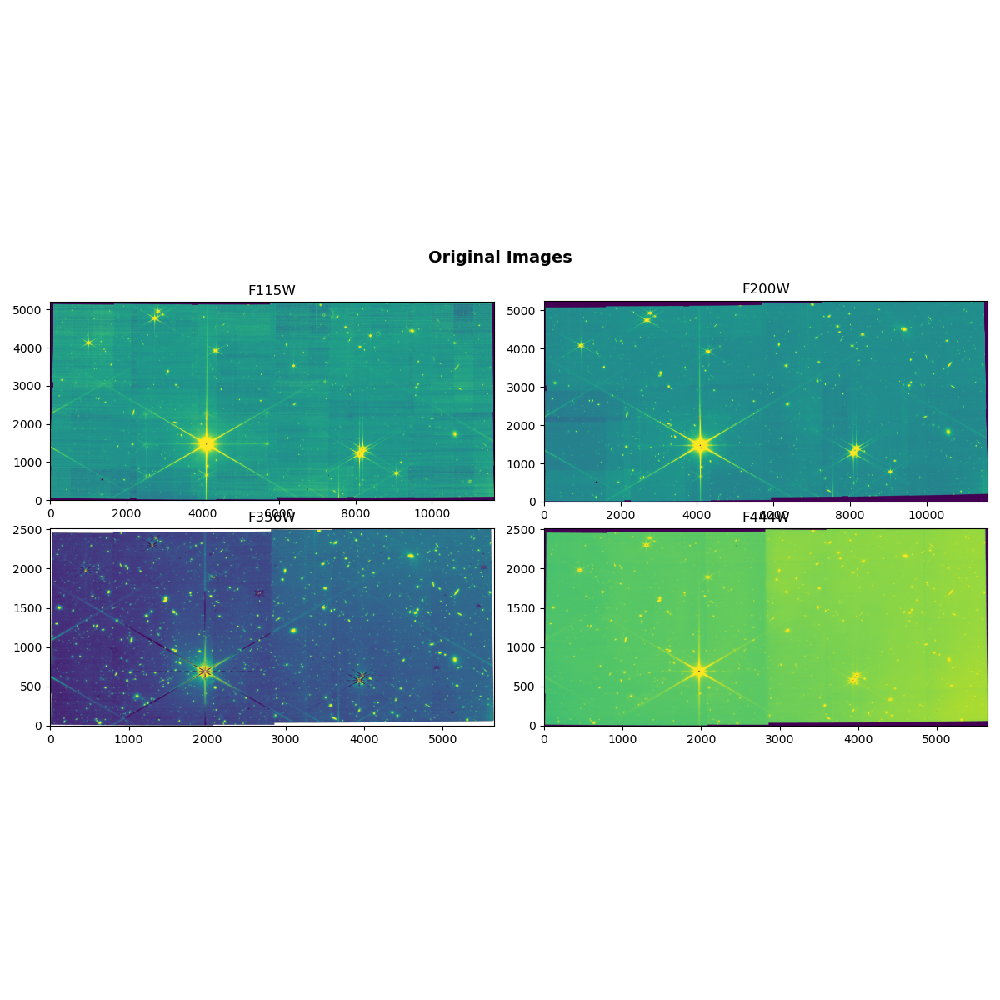

In [167]:
#plot_original()

In [9]:
#plot_background()

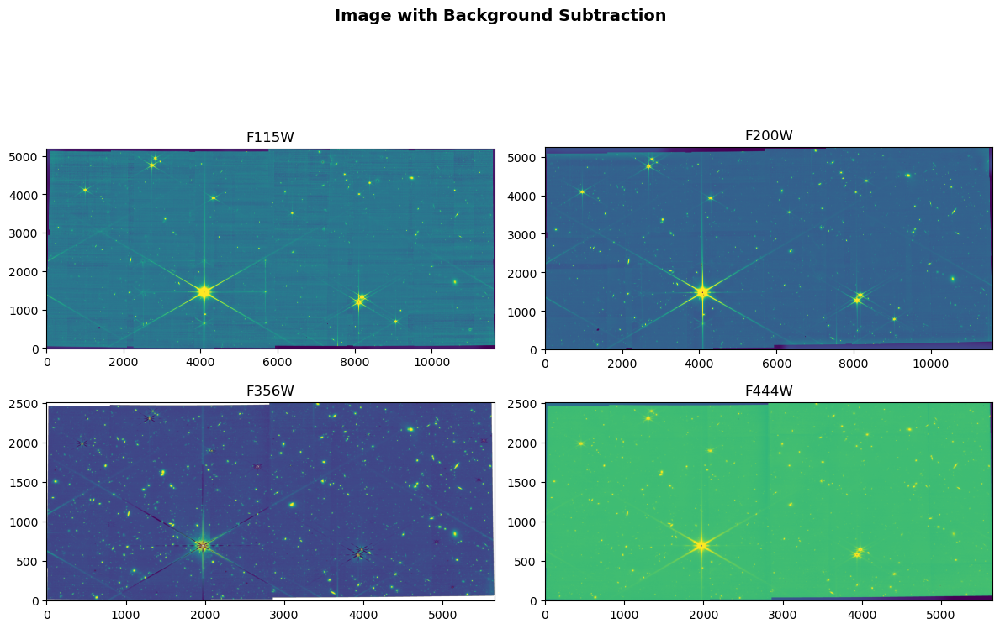

In [9]:
plot_imsubk()

### The cutoff function

In [10]:
wcs_list = [WCS(im['SCI'].header) for im in ims]

Set DATE-AVG to '2022-03-13T06:19:58.985' from MJD-AVG.
Set DATE-END to '2022-03-13T06:34:28.702' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.419235 from OBSGEO-[XYZ].
Set OBSGEO-H to 1341185768.124 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-03-13T05:35:04.035' from MJD-AVG.
Set DATE-END to '2022-03-13T05:58:30.560' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.417868 from OBSGEO-[XYZ].
Set OBSGEO-H to 1341384297.959 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-03-13T05:35:04.069' from MJD-AVG.
Set DATE-END to '2022-03-13T05:58:30.624' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.416530 from OBSGEO-[XYZ].
Set OBSGEO-H to 1341575761.649 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-03-13T06:19:58.989' from MJD-AVG.
Set DATE-END to '2022-03-13T06:34:28.702' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.419235 from OBSGEO-[XYZ].
Set OBSGEO-H to 1341185762.580 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [273]:
#Cutoff function based on a central pixel from F356W
def plot_cutout(pixel_x, pixel_y, size, title):
    box = wcs_list[3].pixel_to_world(pixel_x, pixel_y)
    sizes = [size, size, size//2, size//2]
    cutout = [Cutout2D(im, box, sz, wcs) for im, wcs, sz in zip(im_subbk_list, wcs_list, sizes)]
    norms = [simple_norm(cutout.data, 'asinh', percent = 99.5) for cutout in cutout]
    ra_str = box.ra.to_string(unit='hourangle', precision=2)
    dec_str = box.dec.to_string(precision=2)

    fig, axs = plt.subplots(2,2, figsize=(6,6))
    for ax, cutout, norm, band in zip(axs.flat, cutout, norms, titles):
        ax.imshow(cutout.data, origin = 'lower', norm=norm, cmap='viridis')
        ax.set_title(band)
        ax.grid(False)

    plt.suptitle(f"{title} — RA: {ra_str}, Dec: {dec_str}", fontsize=14, fontweight='bold', color='hotpink')
    plt.tight_layout(h_pad=1)
    plt.show()

In [276]:
#Cutoff function based on a central RA and Dec
def wcs_cutout(ra, dec, size, title):
    sky_coord = SkyCoord(ra=ra, dec=dec, unit='deg')
    sizes = [size, size, size//2, size//2]
    cutout = [Cutout2D(im, sky_coord, sz, wcs=wcs) for im, wcs, sz in zip(im_subbk_list, wcs_list, sizes)]
    norms = [simple_norm(cutout.data, 'asinh', percent = 99.5) for cutout in cutout]

    pixel_x, pixel_y = wcs_list[3].world_to_pixel(sky_coord)

    fig, axs = plt.subplots(2,2, figsize=(6,6))
    for ax, cutout, norm, band in zip(axs.flat, cutout, norms, titles):
        ax.imshow(cutout.data, origin = 'lower', norm=norm, cmap='viridis')
        ax.set_title(band)
        ax.grid(False)

    ra_str=sky_coord.ra.to_string(unit='hourangle', precision=2)
    dec_str = sky_coord.dec.to_string(precision=2)
    
    plt.suptitle(f"{title}\nRA: {ra_str}, Dec:{dec_str})\nPixel: ({pixel_x:1f}, {pixel_y:1f})", 
                 fontsize=14, fontweight='bold', color='hotpink')
    plt.tight_layout(h_pad=1)
    plt.show()

    return pixel_x, pixel_y

#### _Using the cutoff function to zoom in on certain galaxies._

In [14]:
#plot_cutout(1581, 959, 350, title="Two Spirals")

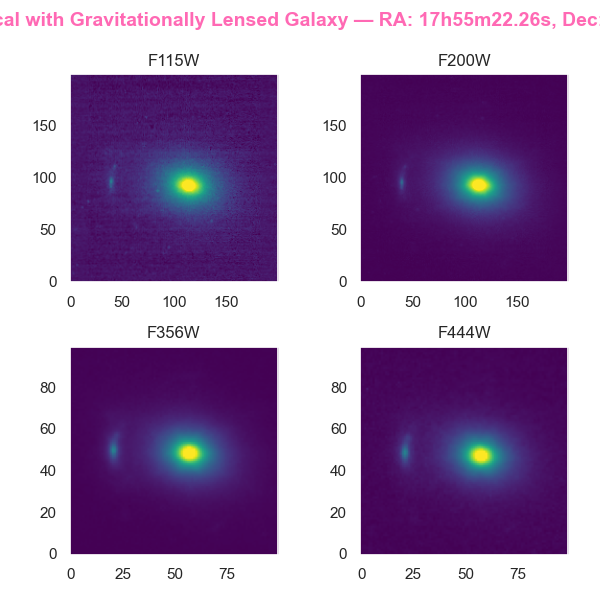

In [274]:
plot_cutout(4586, 2160, 200, title="Massive Elliptical with Gravitationally Lensed Galaxy")

In [16]:
#plot_cutout(4980, 930, 900, title = "Some Spirals")

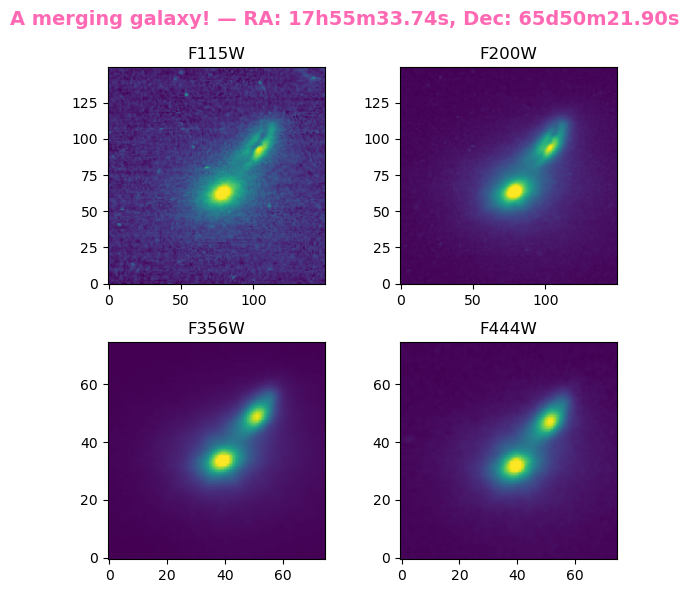

In [17]:
plot_cutout(3087, 1211, 150, title= "A merging galaxy!")

## Image Segmentation and Deblending
#### _This section is dedicated to source detection and creating a catalog to perform aperture photometry and other data analysis in future sections._

In [13]:
#Package Installation
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel

from photutils.segmentation import detect_sources

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize

from photutils.segmentation import deblend_sources
from photutils.segmentation import SourceCatalog
from photutils.utils import calc_total_error
from photutils.segmentation import SourceFinder

from photutils.segmentation import detect_threshold  

from astropy import units as u


In [14]:
kernel = make_2dgaussian_kernel(3.0, size=5)  # FWHM = 3.0
convolved_data = [convolve(im, kernel) for im in im_subbk_list]
#threshold = [detect_threshold(cd, nsigma=4.5) for cd in convolved_data]
threshold = [detect_threshold(cd, nsigma=10) for cd in convolved_data]
segment_map =[detect_sources(cd, thrsh, npixels=20) for cd, thrsh in zip(convolved_data, threshold)]

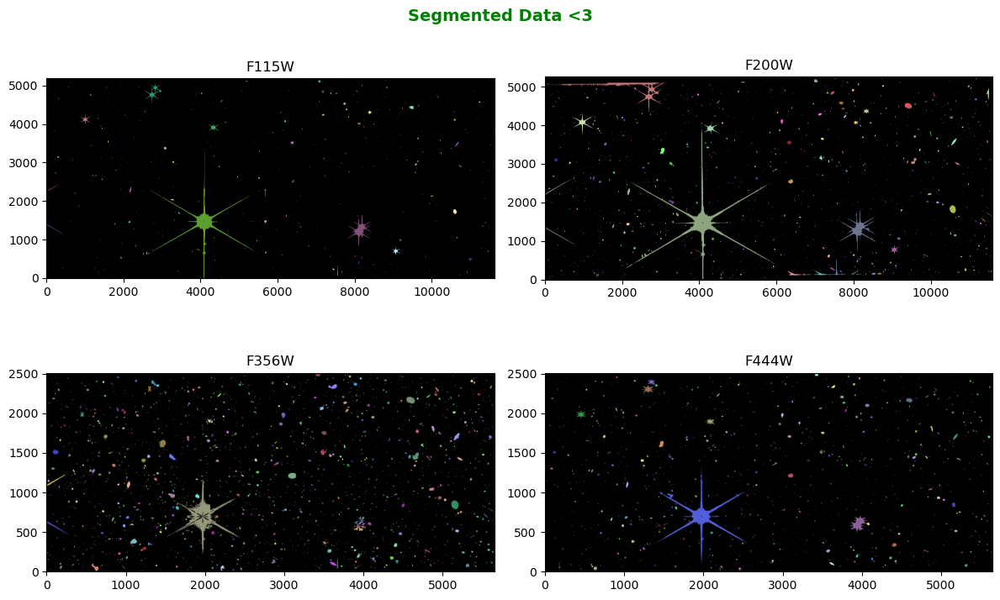

In [20]:
#Viewing segmented image.
fig, axs = plt.subplots(2,2, figsize=(12,12))
for ax, seg, band in zip(axs.flat, segment_map, titles):
    ax.imshow(seg, origin = 'lower', cmap=seg.cmap)
    ax.set_title(band)

plt.suptitle("Segmented Data <3", fontsize=14, fontweight='bold', color='Green', y=.8)
plt.tight_layout(h_pad=-18)
#plt.show();

#### _Time to start deblending_

In [15]:
segm_deblend = [deblend_sources(cd, seg, 
                npixels=10, nlevels=32, contrast=0.001, progress_bar=False)
                for cd, seg in zip(convolved_data, segment_map)]

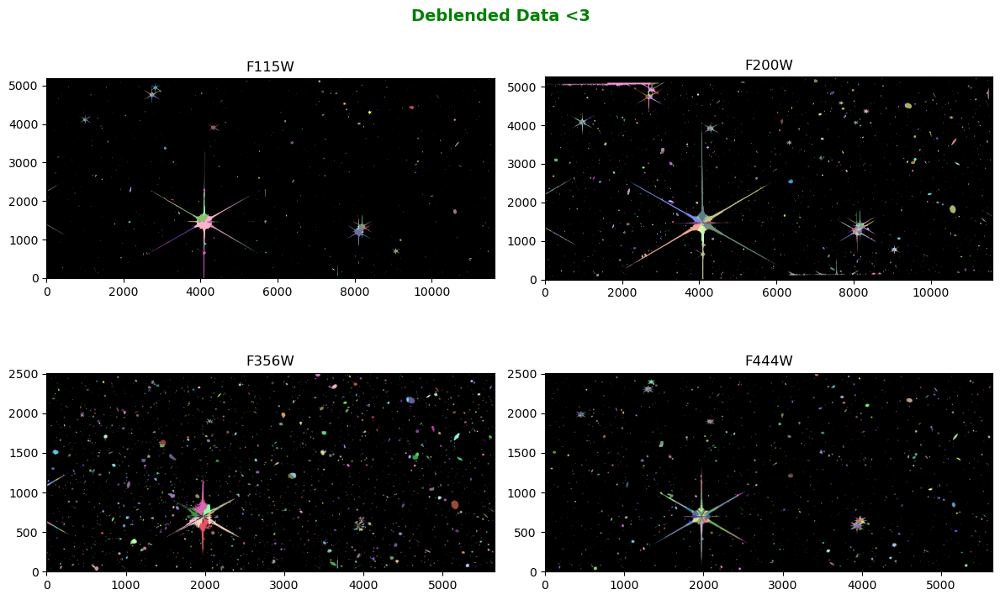

In [22]:
#Viewing deblended data
fig, axs = plt.subplots(2,2, figsize=(12,12))
for ax, seg_d, band in zip(axs.flat, segm_deblend, titles):
    ax.imshow(seg_d, origin = 'lower', cmap=seg_d.cmap)
    ax.set_title(band)

plt.suptitle("Deblended Data <3", fontsize=14, fontweight='bold', color='Green', y=.8)
plt.tight_layout(h_pad=-18)
plt.show();

#### Creating the catalog viewing the apertures..

In [16]:
cat = SourceCatalog(im_subbk_list[2], segm_deblend[2], convolved_data=convolved_data[2], wcs=wcs_list[2])
tbl = cat.to_table()
tbl['xcentroid'].info.format = '.2f'  
tbl['ycentroid'].info.format = '.2f'
tbl['kron_flux'].info.format = '.2f'

#[print(f"{i}: {ap.to_sky(wcs_list[2])}") for i, ap in enumerate(cat.kron_aperture)]


In [17]:
cat_115 = SourceCatalog(im_subbk_list[0], segm_deblend[0], convolved_data=convolved_data[0], wcs=wcs_list[0])
tbl_115 = cat.to_table()
tbl_115['xcentroid'].info.format = '.2f'  
tbl_115['ycentroid'].info.format = '.2f'
tbl_115['kron_flux'].info.format = '.2f'

In [18]:
cat_200 = SourceCatalog(im_subbk_list[1], segm_deblend[1], convolved_data=convolved_data[1], wcs=wcs_list[1])
cat_444 = SourceCatalog(im_subbk_list[3], segm_deblend[3], convolved_data=convolved_data[3], wcs=wcs_list[3])

In [26]:
#tbl_115.write("tbl_115.txt", format="ascii.fixed_width", overwrite=True)

In [27]:
#acc_tbl.write("acc_tbl.txt", format="ascii.fixed_width", overwrite=True)

### Source Selection for Cleaning up Catalog

In [259]:
import os
from matplotlib.widgets import TextBox

def yes_no_source_selection():
    #I want to be able to manually look at each catalog item and press yes or no to decide if I want the item in the catalog

    #Step one is to use my button interactive viewer... yes and no.. yes keeps item in catalog and moves to next item... no takes item out of catalog.. what I'll do is create a new catalog by making a list 
    #With yes on one side and no on the other side.. I can then take this list and turn it into a new catalog by having the yes' corresponf to catalog item numbers 
    #Then I can make new diagrams!!
    class CatalogReviewer:
        def __init__(self, cat):
            self.cat = cat
            self.index = 0
            self.status_file = "catalog_review_status.npy"

            if os.path.exists(self.status_file):
                self.status = np.load(self.status_file).tolist()
            else:
                self.status = [0] * len(cat)
            
            self.fig, self.axs = plt.subplots(2, 4, figsize=(12, 6))
            plt.subplots_adjust(top=.75, bottom=0.2, hspace=.50, wspace=.3)  
    
            # Buttons
            axyes = plt.axes([0.3, 0.05, 0.1, 0.075])
            axno = plt.axes([0.6, 0.05, 0.1, 0.075])
            ax_go = plt.axes([0.45, 0.05, 0.1, 0.075])
            self.byes = Button(axyes, 'Yes')
            self.bno = Button(axno, 'No')
            self.textbox = TextBox(ax_go, 'Go to')
            self.byes.on_clicked(self.yes)
            self.bno.on_clicked(self.no)
            self.textbox.on_submit(self.go_to)
            axmaybe = plt.axes([0.75, 0.05, 0.1, 0.075])
            self.bmaybe = Button(axmaybe, 'Maybe')
            self.bmaybe.on_clicked(self.maybe)
            axskip = plt.axes([0.05, 0.05, 0.2, 0.075])
            self.bskip = Button(axskip, 'Next Undecided')
            self.bskip.on_clicked(self.skip)

            self.text_ax = self.fig.add_axes([0.01, 0.85, .23, .12])
            self.text_ax.axis('off')
            self.text_box=self.text_ax.text( 0, 1, '', ha='left', va='top', fontsize=9, color='black', wrap=True, 
                                             family='monospace')
            #wrap=True

            self.display()    
            plt.show()

        def save_status(self):
            np.save(self.status_file, np.array(self.status))
    
        def display(self):
            i = self.index
            fluxes = [c[i] for c in cat_list]
            ap_sky = self.cat.kron_aperture[i].to_sky(wcs_list[2])
            sky_pos = ap_sky.positions
            cutout_size = 6 * u.arcsec
    
            cutouts_im = [Cutout2D(im, sky_pos, cutout_size, wcs=w) for im, w in zip(im_subbk_list, wcs_list)]
            cutouts_segm = [Cutout2D(seg_d, sky_pos, cutout_size, wcs=w) for seg_d, w in zip(segm_deblend, wcs_list)]
            apertures = [ap_sky.to_pixel(cutout.wcs) for cutout in cutouts_im]
    
            norms_im = [simple_norm(cut.data, 'asinh', percent=99.5) for cut in cutouts_im]
            norms_segd = [simple_norm(cut.data, 'asinh', percent=99.5) for cut in cutouts_segm]
    
            for ax in self.axs.flat:
                ax.clear()
    
            for ax, cutout, ap_pix, norm, band, flux in zip(self.axs[:, :2].flat, cutouts_im, apertures, norms_im, titles, fluxes):
                ax.imshow(cutout.data, origin='lower', cmap='viridis', norm=norm)
                ap_pix.plot(ax=ax, color='lime', lw=1)
                ax.set_title(f"{band}\nFlux: {flux:.2f}")
                ax.grid(False)
    
            for ax, cutout, ap_pix, norm, band, flux, seg_d in zip(self.axs[:, 2:].flat, cutouts_segm, apertures, norms_segd, titles, fluxes, segm_deblend):
                ax.imshow(cutout.data, origin='lower', cmap=seg_d.cmap, norm=norm)
                ap_pix.plot(ax=ax, color='lime', lw=1)
                ax.set_title(f"{band} deblended")
                ax.grid(False)

            status_str = {1: "✔ Accepted", -1: "✘ Rejected", 0: "⏳ Undecided"}
            self.fig.suptitle(f"Source {i} — {status_str[self.status[i]]}", fontsize=14, fontweight='bold', color='hotpink')
            self.fig.canvas.draw_idle()

            ap_text = (
                f"Aperture: SkyEllipticalAperture\n"
                f"positions: <SkyCoord (ICRS): (ra, dec) in deg\n"
                f"    ({ap_sky.positions.ra.deg:.8f}, {ap_sky.positions.dec.deg:.8f})>\n"
                f"a: {ap_sky.a.to_value(u.arcsec):.17f} arcsec\n"
                f"b: {ap_sky.b.to_value(u.arcsec):.17f} arcsec\n"
                f"theta: {ap_sky.theta.to_value(u.rad):.15f} rad"
            )
            self.text_box.set_text(ap_text)
            self.text_ax.figure.canvas.draw_idle()
    
        def yes(self, event):
            self.status[self.index] = 1
            self.save_status()
            self.next()

        def no(self, event):
            self.status[self.index] = -1
            self.save_status()
            self.next()

        def next(self):
            if self.index < len(self.cat) - 1:
                self.index += 1
                self.display()
            else:
                print("Done reviewing!")
                self.finish()
                plt.close(self.fig)

        def maybe(self, event):
            self.status[self.index] = 0
            self.save_status()
            self.next()

        def skip(self, event):
            for i in range(self.index + 1, len(self.cat)):
                if self.status[i] == 0:
                    self.index = i
                    self.display()
                    return
            print("No more undecided items.")


        def go_to(self, text):
            try:
                idx = int(text)
                if 0 <= idx < len(self.cat):
                    self.index = idx
                    self.display()
            except ValueError:
                print("Invalid input. Please ƒenter a number.")

        def finish(self):
            accepted_cat = self.cat[np.array(self.status) == 1]
            accepted_cat.write('accepted_catalog.txt', format='ascii', overwrite=True)
            print("Accepted catalog saved.")
    
    viewer = CatalogReviewer(cat)


/Users/sshapiro/.local/lib/python3.12/site-packages/ipympl/backend_nbagg.py:335: UserWarning: Glyph 10008 (\N{HEAVY BALLOT X}) missing from font(s) Arial.
  self.figure.savefig(buf, format='png', dpi='figure')


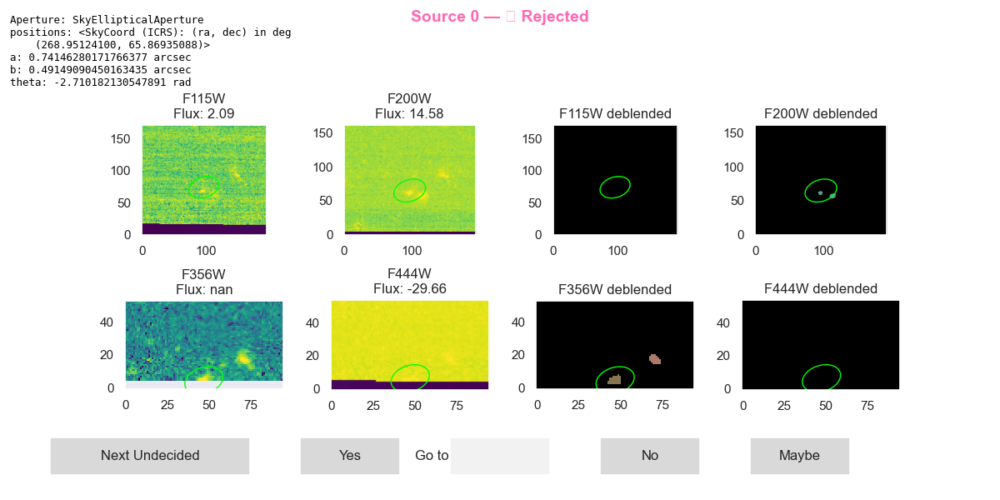

In [260]:
yes_no_source_selection() 

In [19]:
from astropy.table import Table
import numpy as np

acc_tbl = Table.read(
    'acc_cat_table.txt',
    format='ascii.basic',
    delimiter='|',
    guess=False
)


acc_tbl.remove_columns(['col0', '_1'])

acc_tbl.add_column(np.arange(len(acc_tbl)), name='Row', index=0)

acc_tbl.write("acc_tbl.txt", format="ascii.fixed_width", overwrite=True)

#acc_ned_matches_with_index.add_column(np.arange(len(acc_ned_matches)), name='Row', index=0)
#acc_ned_matches_with_index.write("acc_ned_matches_table_1.txt", format="ascii.fixed_width", overwrite=True)

source_table = cat.to_table()

original_labels = np.array(source_table['label'])

acc_labels = np.array(acc_tbl['label'])

# Create a mask for accepted sources
mask = np.isin(original_labels, acc_labels)

# Filter the SourceCatalog by mask
acc_cat = cat[mask]


In [20]:
print(acc_tbl.colnames)

['Row', 'label', 'xcentroid', 'ycentroid', 'sky_centroid', 'bbox_xmin', 'bbox_xmax', 'bbox_ymin', 'bbox_ymax', 'area', 'semimajor_sigma', 'semiminor_sigma', 'orientation', 'eccentricity', 'min_value', 'max_value', 'local_background', 'segment_flux', 'segment_fluxerr', 'kron_flux', 'kron_fluxerr']


In [21]:
# acc_cat is a photutils SourceCatalog object
x_positions = acc_cat.xcentroid  # This is a numpy array of x coordinates
y_positions = acc_cat.ycentroid  # numpy array of y coordinates

positions = list(zip(x_positions, y_positions))


## Morphological Classification

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
from astropy.nddata import Cutout2D
import astropy.units as u

def morphology_classification():
    class MorphologyReviewer:
        def __init__(self, acc_cat):
            self.cat = acc_cat
            self.index = 0
            self.status_file = "acc_catalog_review_status.npy"
            self.labels = ["Undecided", "Irregular", "Spiral", "Elliptical", "Point Source"]
            
            if os.path.exists(self.status_file):
                self.status = np.load(self.status_file).tolist()
            else:
                self.status = ["Undecided"] * len(acc_cat)

            self.fig, self.axs = plt.subplots(2, 4, figsize=(12, 6))
            plt.subplots_adjust(top=.75, bottom=0.2, hspace=.50, wspace=.3)  

            # Buttons for each classification
            ax_irreg = plt.axes([0.1, 0.05, 0.12, 0.075])
            ax_spiral = plt.axes([0.23, 0.05, 0.12, 0.075])
            ax_ellip = plt.axes([0.36, 0.05, 0.12, 0.075])
            ax_point = plt.axes([0.49, 0.05, 0.12, 0.075])
            ax_undec = plt.axes([0.62, 0.05, 0.12, 0.075])
            ax_go = plt.axes([0.8, 0.05, 0.1, 0.075])
            ax_skip = plt.axes([0.01, 0.86, 0.2, 0.06])

            self.birreg = Button(ax_irreg, 'Irregular')
            self.bspiral = Button(ax_spiral, 'Spiral')
            self.bellip = Button(ax_ellip, 'Elliptical')
            self.bpoint = Button(ax_point, 'Point Src')
            self.bundec = Button(ax_undec, 'Undecided')
            self.textbox = TextBox(ax_go, 'Go to')
            self.bskip = Button(ax_skip, 'Next Undecided')

            self.birreg.on_clicked(lambda event: self.set_class("Irregular"))
            self.bspiral.on_clicked(lambda event: self.set_class("Spiral"))
            self.bellip.on_clicked(lambda event: self.set_class("Elliptical"))
            self.bpoint.on_clicked(lambda event: self.set_class("Point Source"))
            self.bundec.on_clicked(lambda event: self.set_class("Undecided"))
            self.textbox.on_submit(self.go_to)
            self.bskip.on_clicked(self.skip)

            self.text_ax = self.fig.add_axes([0.75, 0.86, 0.23, 0.12])
            self.text_ax.axis('off')
            self.text_box = self.text_ax.text(0, 1, '', ha='left', va='top', fontsize=9, wrap=True, family='monospace')

            self.display()
            plt.show()

        def save_status(self):
            np.save(self.status_file, np.array(self.status))

        def set_class(self, label):
            self.status[self.index] = label
            self.save_status()
            self.next()

        def display(self):
            i = self.index
            fluxes = [c[i] for c in cat_list]  # Assumes cat_list is defined in scope
            ap_sky = self.cat.kron_aperture[i].to_sky(wcs_list[2])  # Assumes wcs_list is defined in scope
            sky_pos = ap_sky.positions
            cutout_size = 6 * u.arcsec

            cutouts_im = [Cutout2D(im, sky_pos, cutout_size, wcs=w) for im, w in zip(im_subbk_list, wcs_list)]
            cutouts_segm = [Cutout2D(seg_d, sky_pos, cutout_size, wcs=w) for seg_d, w in zip(segm_deblend, wcs_list)]
            apertures = [ap_sky.to_pixel(cutout.wcs) for cutout in cutouts_im]

            norms_im = [simple_norm(cut.data, 'asinh', percent=99.5) for cut in cutouts_im]
            norms_segd = [simple_norm(cut.data, 'asinh', percent=99.5) for cut in cutouts_segm]

            for ax in self.axs.flat:
                ax.clear()

            for ax, cutout, ap_pix, norm, band, flux in zip(self.axs[:, :2].flat, cutouts_im, apertures, norms_im, titles, fluxes):
                ax.imshow(cutout.data, origin='lower', cmap='viridis', norm=norm)
                ap_pix.plot(ax=ax, color='lime', lw=1)
                ax.set_title(f"{band}\nFlux: {flux:.2f}")
                ax.grid(False)

            for ax, cutout, ap_pix, norm, band, flux, seg_d in zip(self.axs[:, 2:].flat, cutouts_segm, apertures, norms_segd, titles, fluxes, segm_deblend):
                ax.imshow(cutout.data, origin='lower', cmap=seg_d.cmap, norm=norm)
                ap_pix.plot(ax=ax, color='lime', lw=1)
                ax.set_title(f"{band} deblended")
                ax.grid(False)

            self.fig.suptitle(f"Source {i} — Class: {self.status[i]}", fontsize=14, fontweight='bold', color='hotpink')
            ap_text = (
                f"Aperture: SkyEllipticalAperture\n"
                f"positions: <SkyCoord (ICRS): (ra, dec) in deg\n"
                f"    ({ap_sky.positions.ra.deg:.8f}, {ap_sky.positions.dec.deg:.8f})>\n"
                f"a: {ap_sky.a.to_value(u.arcsec):.17f} arcsec\n"
                f"b: {ap_sky.b.to_value(u.arcsec):.17f} arcsec\n"
                f"theta: {ap_sky.theta.to_value(u.rad):.15f} rad"
            )
            self.text_box.set_text(ap_text)
            self.fig.canvas.draw_idle()

        def next(self):
            if self.index < len(self.cat) - 1:
                self.index += 1
                self.display()
            else:
                print("Done reviewing!")
                self.finish()
                plt.close(self.fig)

        def skip(self, event):
            for i in range(self.index + 1, len(self.cat)):
                if self.status[i] == "Undecided":
                    self.index = i
                    self.display()
                    return
            print("No more undecided items.")

        def go_to(self, text):
            try:
                idx = int(text)
                if 0 <= idx < len(self.cat):
                    self.index = idx
                    self.display()
            except ValueError:
                print("Invalid input.")

        def finish(self):
            np.save(self.status_file, np.array(self.status))
            print("Morphological classifications saved.")

    viewer = MorphologyReviewer(acc_cat)


### Seeing which values from each catalog match the accepted catalog

In [26]:
import pandas as pd

def catalog_matching_single(cat, ref_sc, ref_tbl, ref_name='accepted_cat', max_sep=1.0 * u.arcsec):
    idx, d2d, d3d = cat.sky_centroid.match_to_catalog_3d(ref_sc)
    sep_constraint = d2d < max_sep
    c_matches = cat.sky_centroid[sep_constraint]
    catalog_matches = ref_sc[idx[sep_constraint]]

    results = []

    for j, coord in enumerate(catalog_matches):
        sep = coord.separation(ref_sc)
        match_index = sep.argmin()
        if sep[match_index] < max_sep:
            # Safely retrieve label based on ref_tbl type
            try:
                label = ref_tbl['label'][match_index]  # astropy Table            
                
            except (TypeError, KeyError, IndexError):
                label = ref_tbl.labels[match_index]   # SourceCatalog

            print(f"Index {j} matches label: {label}")  
            print(f"  Original: RA={c_matches[j].ra.deg:.6f}, Dec={c_matches[j].dec.deg:.6f}")
            print(f"  Matched : RA={catalog_matches[j].ra.deg:.6f}, Dec={catalog_matches[j].dec.deg:.6f}, Distance={d2d[j].arcsec}")
            print()

            results.append([f'{ref_name}_Item_{j}', label])

    catalog_matching_df = pd.DataFrame(results, columns=['Item Name', 'Value'])
    return catalog_matching_df


In [28]:
# Setup
ref_tbl = acc_cat
ref_sc = ref_tbl.sky_centroid

matched_115 = catalog_matching_single(cat_115, ref_sc, ref_tbl, ref_name='cat115')
matched_200 = catalog_matching_single(cat_200, ref_sc, ref_tbl, ref_name='cat200')
matched_444 = catalog_matching_single(cat_444, ref_sc, ref_tbl, ref_name='cat444')


Index 0 matches label: 5
  Original: RA=268.944871, Dec=65.849619
  Matched : RA=268.944762, Dec=65.849612, Distance=2.734431082387771

Index 1 matches label: 7
  Original: RA=268.947602, Dec=65.859568
  Matched : RA=268.947517, Dec=65.859568, Distance=2.9977720731958657

Index 2 matches label: 14
  Original: RA=268.941801, Dec=65.841869
  Matched : RA=268.941697, Dec=65.841858, Distance=6.830644907607257

Index 3 matches label: 1929
  Original: RA=268.953342, Dec=65.879533
  Matched : RA=268.952858, Dec=65.879534, Distance=3.241541173127562

Index 4 matches label: 24
  Original: RA=268.933597, Dec=65.816618
  Matched : RA=268.933489, Dec=65.816599, Distance=4.937099611903105

Index 5 matches label: 1929
  Original: RA=268.952983, Dec=65.879531
  Matched : RA=268.952858, Dec=65.879534, Distance=3.661708090727783

Index 6 matches label: 25
  Original: RA=268.934407, Dec=65.819585
  Matched : RA=268.934290, Dec=65.819578, Distance=3.5190469110682745

Index 7 matches label: 30
  Original:

In [27]:
matched_115 = catalog_matching_single(cat_115, ref_sc, ref_tbl, ref_name='cat115')

NameError: name 'ref_sc' is not defined

In [29]:
from collections import defaultdict

def count_unique_and_repeats_df(catalog_matching_df, value_column='Value'):
    name_to_rows = defaultdict(list)
    for i, name in enumerate(catalog_matching_df[value_column]):
        name_to_rows[name].append(i)

    unique_count = sum(1 for rows in name_to_rows.values() if len(rows) == 1)
    repetitive_groups = [rows for rows in name_to_rows.values() if len(rows) > 1]
    repetitive_group_count = len(repetitive_groups)
    return unique_count, repetitive_group_count, repetitive_groups


#for name, rows in name_to_rows.items():
   # if len(rows) > 1:
     #   print(f'{count}: Source "{name}" repeats in rows: {rows}')
     #   count+=1
     

In [139]:
len(acc_cat)

1781

In [30]:
unique_115, repeats_115, repeat_groups_115 = count_unique_and_repeats_df(matched_115)
unique_200, repeats_200, repeat_groups_200 = count_unique_and_repeats_df(matched_200)
unique_444, repeats_444, repeat_groups_444 = count_unique_and_repeats_df(matched_444)

print(f"\ncat_115: {unique_115} unique, {repeats_115} repetitive groups")
print(f"cat_200: {unique_200} unique, {repeats_200} repetitive groups")
print(f"cat_444: {unique_444} unique, {repeats_444} repetitive groups")



cat_115: 439 unique, 61 repetitive groups
cat_200: 1265 unique, 238 repetitive groups
cat_444: 878 unique, 14 repetitive groups


In [31]:
from astropy.wcs.utils import pixel_to_skycoord

skycoords = pixel_to_skycoord(tbl['xcentroid'], tbl['ycentroid'], wcs_list[2])
tbl['ra'] = skycoords.ra.deg
tbl['dec'] = skycoords.dec.deg


In [32]:
acc_skycoords = pixel_to_skycoord(acc_tbl['xcentroid'], acc_tbl['ycentroid'], wcs_list[2])
acc_tbl['ra'] = acc_skycoords.ra.deg
acc_tbl['dec'] = acc_skycoords.dec.deg

In [38]:
#import numpy as np

#status = np.load("catalog_review_status.npy")

#accepted_cat = cat[np.array(status) == 1]


In [39]:
#acc_tbl = accepted_cat.to_table()
#acc_tbl['xcentroid'].info.format = '.2f'  # optional format
#acc_tbl['ycentroid'].info.format = '.2f'
#acc_tbl['kron_flux'].info.format = '.2f'

#[print(f"{i}: {ap.to_sky(wcs_list[2])}") for i, ap in enumerate(cat.kron_aperture)]


In [40]:
#accepted_cat_table = accepted_cat.to_table()
#accepted_cat_table.write("acc_cat_table.txt", format="ascii.fixed_width", overwrite=True)


In [41]:
#print(acc_cat_table)

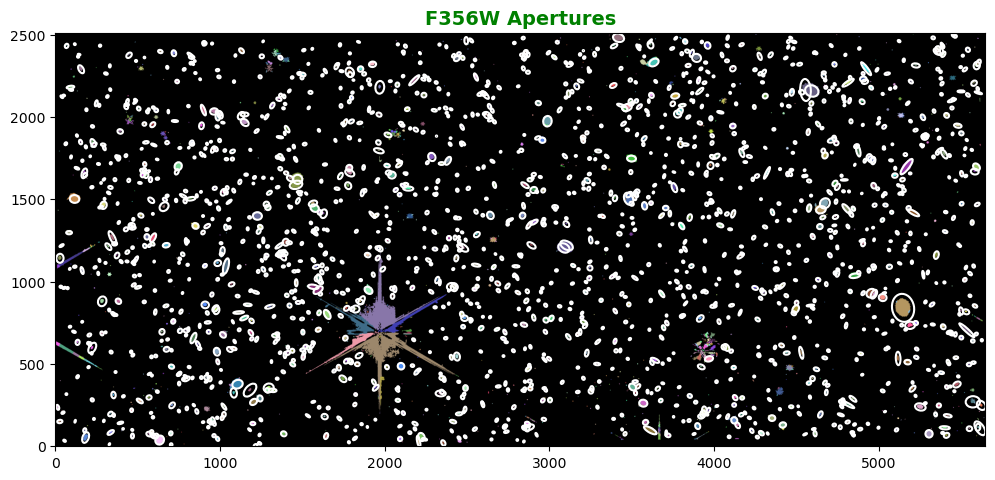

In [43]:
def segmentation_kron():
    #norm = [simple_norm(im, 'asinh', percent = 99.5)for im in im_subbk_list]

    plt.figure(figsize = [12, 12])
    plt.imshow(segm_deblend[2], origin = 'lower', cmap=seg_d.cmap)
    plt.title("F356W Apertures", fontsize=14, fontweight='bold', color='Green')
    acc_cat.plot_kron_apertures(color = 'white', lw=1.5)
    
   # fig, axs = plt.subplots(2,2, figsize=(12,12))
    #for ax, seg_d, band in zip(axs.flat, segm_deblend, titles):
        #ax.imshow(seg_d, origin = 'lower', cmap=seg_d.cmap)
        #ax.set_title(band)
        #cat.plot_kron_apertures(ax=ax, color='white', lw=1.5)

    #plt.suptitle("Segmentation with Kron Apertures", fontsize=14, fontweight='bold', color='Green', y=.8)
    #plt.tight_layout(h_pad=-18)
    plt.show();

segmentation_kron()

### Creating Fluxes

In [33]:
from photutils.aperture import aperture_photometry

In [34]:
cat_list=[]

for im, wcs in zip(im_subbk_list, wcs_list):
    band_fluxes= [
    aperture_photometry(im, cat.kron_aperture[i].to_sky(wcs_list[2]), wcs=wcs)['aperture_sum'].value[0] 
    for i in range(len(cat))
    ]
    cat_list.append(band_fluxes)

In [35]:
acc_cat_list=[]

for im, wcs in zip(im_subbk_list, wcs_list):
    acc_band_fluxes= [
    aperture_photometry(im, acc_cat.kron_aperture[i].to_sky(wcs_list[2]), wcs=wcs)['aperture_sum'].value[0] 
    for i in range(len(acc_cat))
    ]
    acc_cat_list.append(acc_band_fluxes)

In [36]:
%matplotlib widget

In [68]:
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
import numpy as np
import os

class SimpleClassifier:
    def __init__(self, num_sources, status_file="simple_review_status.npy"):
        self.num_sources = num_sources
        self.index = 0
        self.status_file = status_file
        self.labels = ["Undecided", "Irregular", "Spiral", "Elliptical", "Point Source"]

        if os.path.exists(self.status_file):
            self.status = np.load(self.status_file).tolist()
        else:
            self.status = ["Undecided"] * num_sources

        self.fig, self.ax = plt.subplots(figsize=(9, 3))
        self.ax.axis('off')
        self.fig.subplots_adjust(bottom=0.35)

        self.text_box = self.ax.text(0.5, 0.6, "", ha='center', va='center', fontsize=18)

        self._init_widgets()
        self.display()

    def _init_widgets(self):
        btn_width = 0.11
        btn_height = 0.08
        spacing = 0.03
        start_x = 0.05
        y_pos = 0.15

        labels = ["Irregular", "Spiral", "Elliptical", "Point Source", "Undecided"]
        self.buttons = {}

        for i, label in enumerate(labels):
            ax = self.fig.add_axes([start_x + i*(btn_width + spacing), y_pos, btn_width, btn_height])
            btn = Button(ax, label)
            btn.on_clicked(lambda event, lab=label: self.set_class(lab))
            self.buttons[label] = btn

        # Skip Button
        ax_skip = self.fig.add_axes([start_x + 5*(btn_width + spacing), y_pos, btn_width, btn_height])
        self.bskip = Button(ax_skip, "Next Undecided")
        self.bskip.on_clicked(self.skip)

        # Go To TextBox
        ax_goto = self.fig.add_axes([start_x + 6*(btn_width + spacing), y_pos, btn_width, btn_height])
        self.textbox = TextBox(ax_goto, 'Go to')
        self.textbox.on_submit(self.go_to)

    def save_status(self):
        np.save(self.status_file, np.array(self.status))

    def display(self):
        self.text_box.set_text(f"Source {self.index} — Class: {self.status[self.index]}")
        self.fig.canvas.draw_idle()

    def set_class(self, label):
        if self.index >= self.num_sources:
            return
        self.status[self.index] = label
        self.save_status()
        self.next()

    def next(self):
        if self.index < self.num_sources - 1:
            self.index += 1
            self.display()
        else:
            print("All sources reviewed.")
            self.save_status()
            plt.close(self.fig)

    def skip(self, event):
        for i in range(self.index + 1, self.num_sources):
            if self.status[i] == "Undecided":
                self.index = i
                self.display()
                return
        print("No more undecided sources.")
        self.save_status()
        plt.close(self.fig)

    def go_to(self, text):
        try:
            idx = int(text)
            if 0 <= idx < self.num_sources:
                self.index = idx
                self.display()
            else:
                print("Index out of range.")
        except ValueError:
            print("Invalid index input.")

# Usage example:
# num_sources = 100  # Replace with your number of sources
# sc = SimpleClassifier(num_sources)


In [104]:
_last_cutout_viewer = None


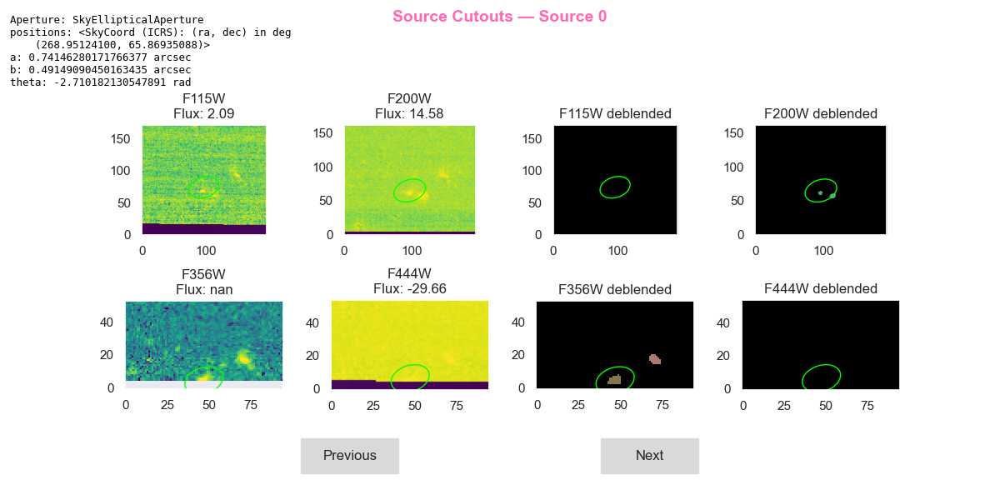

In [115]:
Cutout_Button(acc_cat, i=0)

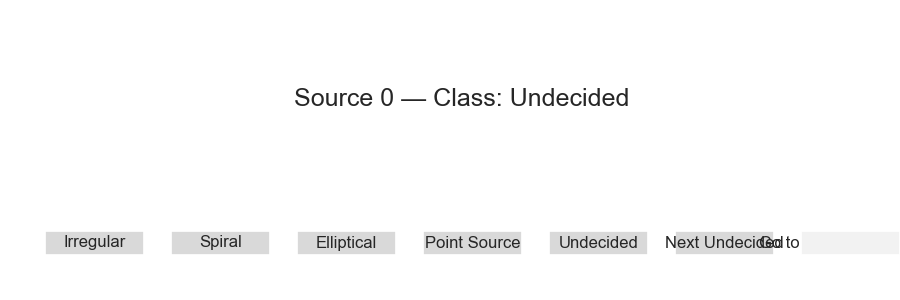

In [118]:
num_sources = len(acc_cat)  # or just set a number like 100
sc = SimpleClassifier(num_sources)


In [261]:
#This function allows you to view a source based on its catalog #.. it gives you the visualized source as well as it segmented for all 4 filters
def plot_source_cutouts(cat, i, title="Source Cutouts"):
    fluxes=[(c[i])for c in cat_list]
    
    ap_sky = cat.kron_aperture[i].to_sky(wcs_list[2])
    sky_pos = ap_sky.positions
    cutout_size = 6 * u.arcsec  

    cutouts_im=[Cutout2D(im, sky_pos, cutout_size, wcs=w) for im, w in zip(im_subbk_list, wcs_list)]
    cutouts_segm=[Cutout2D(seg_d, sky_pos, cutout_size, wcs=w) for seg_d, w in zip(segm_deblend, wcs_list)]

    apertures = [ap_sky.to_pixel(cutout.wcs) for cutout in cutouts_im]
    
    norms_im = [simple_norm(cuts.data, 'asinh', percent=99.5) for cuts in cutouts_im]
    norms_segd = [simple_norm(cuts.data, 'asinh', percent=99.5) for cuts in cutouts_segm]
 
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))

    for ax, cutout, ap_pix, norm, band, flux in zip(axs[:, :2].flat, cutouts_im, apertures, norms_im, titles, fluxes):
        ax.imshow(cutout.data, origin='lower', cmap='viridis', norm=norm)
        ap_pix.plot(ax=ax, color='lime', lw=1)
        ax.set_title(f"{band}\nFlux: {flux:.2f}")
        ax.grid(False)

    for ax, cutout, ap_pix, norm, band, flux, seg_d in zip(axs[:, 2:].flat, cutouts_segm, apertures, norms_segd, titles, fluxes, segm_deblend):
        ax.imshow(cutout.data, origin='lower', cmap=seg_d.cmap, norm=norm)
        ap_pix.plot(ax=ax, color='lime', lw=1)
        ax.set_title(f"{band} deblended")
        ax.grid(False)
    

    plt.suptitle(f"{title} — Source {i}", fontsize=14, fontweight='bold', color='hotpink')
    plt.tight_layout(h_pad=1)
    plt.show()
    print(cat.kron_aperture[i].to_sky(wcs_list[2]))

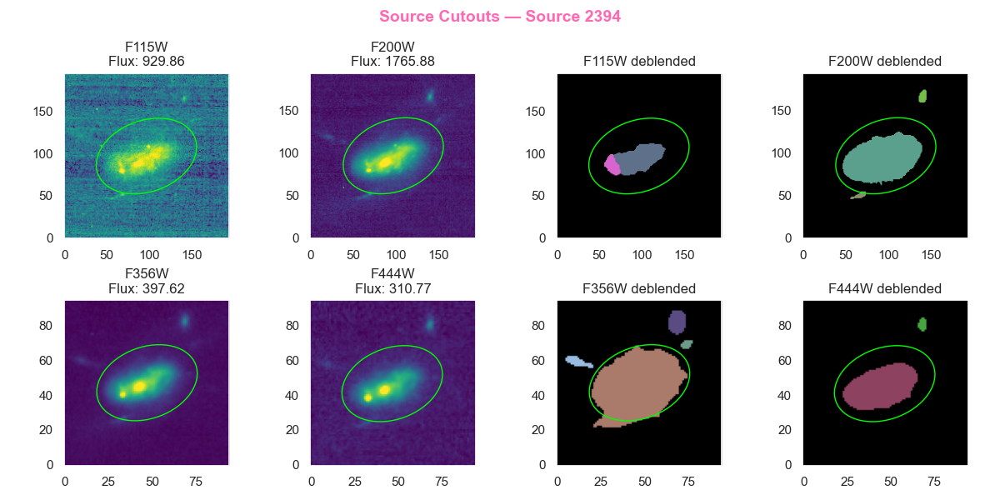

Aperture: SkyEllipticalAperture
positions: <SkyCoord (ICRS): (ra, dec) in deg
    (268.85270204, 65.8345047)>
a: 1.8751203774089449 arcsec
b: 1.2895617575510328 arcsec
theta: -2.6687609667034415 rad


In [264]:
plot_source_cutouts(cat, i=2394)

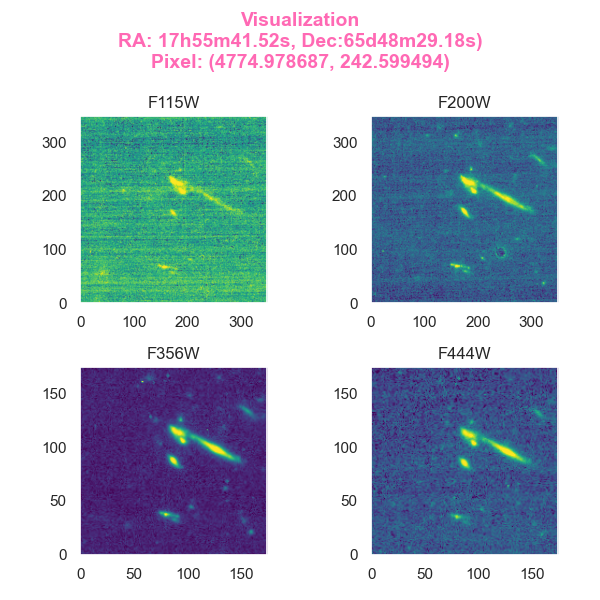

(array(4774.97868672), array(242.59949367))

In [278]:
wcs_cutout(268.9230003183987, 65.80810633526305, 350, title="Visualization")


In [123]:
def Cutout_Button(cat, i):
    from matplotlib.widgets import Button
    import matplotlib.pyplot as plt
    global _last_cutout_viewer

    # Close previous viewer figure if one exists
    if _last_cutout_viewer is not None:
        try:
            plt.close(_last_cutout_viewer.fig)
        except:
            pass

    class CutoutViewer:
        def __init__(self, cat):
            self.cat = cat
            self.index = i
            self.fig, self.axs = plt.subplots(2, 4, figsize=(12, 6))
            plt.subplots_adjust(top=.75, bottom=0.2, hspace=.50, wspace=.3)

            # Buttons
            axprev = plt.axes([0.3, 0.05, 0.1, 0.075])
            axnext = plt.axes([0.6, 0.05, 0.1, 0.075])
            self.bnext = Button(axnext, 'Next')
            self.bprev = Button(axprev, 'Previous')
            self.bnext.on_clicked(self.next)
            self.bprev.on_clicked(self.prev)

            self.text_ax = self.fig.add_axes([0.01, 0.85, .23, .12])
            self.text_ax.axis('off')
            self.text_box = self.text_ax.text(
                0, 1, '', ha='left', va='top', fontsize=9, color='black', wrap=True, family='monospace'
            )

            self.update()
            plt.show()

        def update(self):
            i = self.index
            fluxes = [c[i] for c in acc_cat_list]
            ap_sky = self.cat.kron_aperture[i].to_sky(wcs_list[2])
            sky_pos = ap_sky.positions
            cutout_size = 6 * u.arcsec

            cutouts_im = [Cutout2D(im, sky_pos, cutout_size, wcs=w) for im, w in zip(im_subbk_list, wcs_list)]
            cutouts_segm = [Cutout2D(seg_d, sky_pos, cutout_size, wcs=w) for seg_d, w in zip(segm_deblend, wcs_list)]
            apertures = [ap_sky.to_pixel(cutout.wcs) for cutout in cutouts_im]

            norms_im = [simple_norm(cut.data, 'asinh', percent=99.5) for cut in cutouts_im]
            norms_segd = [simple_norm(cut.data, 'asinh', percent=99.5) for cut in cutouts_segm]

            for ax in self.axs.flat:
                ax.clear()

            for ax, cutout, ap_pix, norm, band, flux in zip(self.axs[:, :2].flat, cutouts_im, apertures, norms_im, titles, fluxes):
                ax.imshow(cutout.data, origin='lower', cmap='viridis', norm=norm)
                ap_pix.plot(ax=ax, color='lime', lw=1)
                ax.set_title(f"{band}\nFlux: {flux:.2f}")
                ax.grid(False)

            for ax, cutout, ap_pix, norm, band, flux, seg_d in zip(self.axs[:, 2:].flat, cutouts_segm, apertures, norms_segd, titles, fluxes, segm_deblend):
                ax.imshow(cutout.data, origin='lower', cmap=seg_d.cmap, norm=norm)
                ap_pix.plot(ax=ax, color='lime', lw=1)
                ax.set_title(f"{band} deblended")
                ax.grid(False)

            self.fig.suptitle(f"Source Cutouts — Source {i}", fontsize=14, fontweight='bold', color='hotpink')
            self.fig.canvas.draw_idle()

            ap = self.cat.kron_aperture[i].to_sky(wcs_list[2])
            ap_text = (
                f"Aperture: SkyEllipticalAperture\n"
                f"positions: <SkyCoord (ICRS): (ra, dec) in deg\n"
                f"    ({ap.positions.ra.deg:.8f}, {ap.positions.dec.deg:.8f})>\n"
                f"a: {ap.a.to_value(u.arcsec):.17f} arcsec\n"
                f"b: {ap.b.to_value(u.arcsec):.17f} arcsec\n"
                f"theta: {ap.theta.to_value(u.rad):.15f} rad"
            )
            self.text_box.set_text(ap_text)
            self.text_ax.figure.canvas.draw_idle()

        def next(self, event):
            if self.index < len(self.cat) - 1:
                self.index += 1
                self.update()

        def prev(self, event):
            if self.index > 0:
                self.index -= 1
                self.update()

    viewer = CutoutViewer(cat)
    _last_cutout_viewer = viewer


IndexError: list index out of range

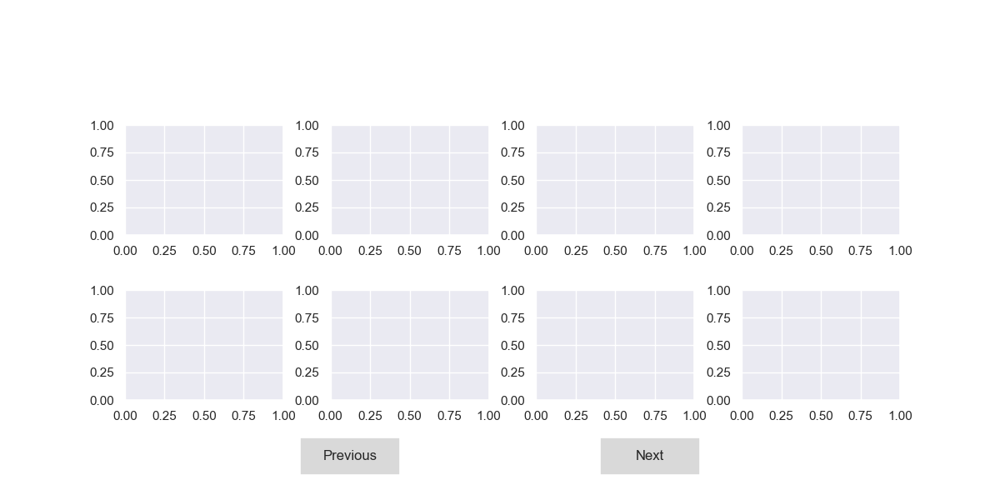

In [267]:
Cutout_Button(cat, i=2394)

## Creating a color-color diagram
#### _This section creates a few different functions for different options in viewing color-color diagram. The main method being to be able to select any item and view it's cutout in 356 filter_

In [125]:
#Flux definition
fluxes = np.array(acc_cat_list)
flux_115 = fluxes[0]
flux_200 = fluxes[1]
flux_356 = fluxes[2]
flux_444 = fluxes[3]


#### Creating flux dataset to use with seaborn visualization

In [126]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

def plot_sed(df_long, item_number, log_y=False, show=True, smooth=True):
    """
    Plot the SED for a single item using its flux ratios with optional smoothing.
    
    Parameters:
        df_long (pd.DataFrame): Long-format DataFrame with 'Item #', 'Flux', 'Ratio'.
        item_number (int): The ID of the item to plot.
        log_y (bool): Whether to use a log scale on the y-axis.
        show (bool): Whether to show the plot.
        smooth (bool): Whether to smooth the curve using spline interpolation.
    """
    item_data = df_long[df_long["Item #"] == item_number]

    if item_data.empty:
        print(f"No data found for Item #{item_number}")
        return

    # Sort by wavelength just in case
    item_data = item_data.sort_values(by="Flux")
    x = item_data["Flux"].values / 100
    y = item_data["Ratio"].values

    plt.figure(figsize=(6, 4))
    
    if smooth and len(x) >= 3:
        # Only smooth if enough points
        x_new = np.linspace(x.min(), x.max(), 200)
        spline = make_interp_spline(x, y, k=2 if len(x) == 3 else 3)  # k=3 for cubic, k=2 for quadratic
        y_smooth = spline(x_new)
        plt.plot(x_new, y_smooth, label=f"Item #{item_number}", color="blue")
    else:
        plt.plot(x, y, marker="o", linestyle="-", label=f"Item #{item_number}", color="blue")

    plt.scatter(x, y, color="black", zorder=5)  # Optional: show actual data points
    plt.title(f"SED for Item #{item_number}")
    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Flux Ratio")
    if log_y:
        plt.yscale("log")
    plt.grid(True)
    plt.tight_layout()

    if show:
        plt.show()


In [128]:
plot_sed(results, item_number = 1748)

NameError: name 'results' is not defined

In [ ]:
# Import seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()

# Load an example dataset
tips = sns.load_dataset("tips")

# Create a visualization
sns.relplot(
    data=tips,
    x="total_bill", y="tip", col="time",
    hue="smoker", style="smoker", size="size",
)

In [131]:
fluxes_transposed = fluxes.T

In [132]:
fluxes_df = pd.DataFrame(fluxes_transposed, columns=['flux_115', 'flux_200', 'flux_356', 'flux_444'])
print(fluxes_df)

        flux_115    flux_200   flux_356   flux_444
0       2.087531   14.580352        NaN -29.663649
1      47.559850   21.301501        NaN -18.421297
2      14.480443    4.932095        NaN  -7.451627
3      84.714625   88.999162        NaN -24.648260
4       5.953844   11.384561   2.222228  -1.946618
...          ...         ...        ...        ...
1776  173.958974  446.228518  89.181357  92.839135
1777  178.016752  414.805196  94.124605  76.007404
1778   49.362783   66.010598  17.908231  17.434983
1779   20.655412   30.239069   4.538176   5.251285
1780   55.487554  100.172761        NaN  20.443079

[1781 rows x 4 columns]


In [213]:
fluxes_df.to_csv("my_data_fluxes.csv", index=False)

In [141]:
bands = ['115', '200', '356', '444']

# Prepare rows for the new DataFrame
rows = []

for i, row in fluxes_df.iterrows():
    for band in bands:
        ratio_col = f"{band}_ratio"
        flux_col = f"flux_{band}"
        ratio = row[ratio_col]
        if pd.notna(ratio):
            rows.append({
                "Item #": i,
                "Flux": int(band),
                "Ratio": ratio,
                "Flux Value": row[flux_col]
            })

# Create new DataFrame
result = pd.DataFrame(rows)

# Optional: Save to CSV
result.to_csv("reshaped_data.csv", index=False)

# Preview
print(result)


      Item #  Flux     Ratio  Flux Value
0          4   115  2.679222    5.953844
1          4   200  5.123038   11.384561
2          4   356  1.000000    2.222228
3          4   444 -0.875976   -1.946618
4          5   115  2.589192   20.750970
...      ...   ...       ...         ...
7023    1778   444  0.973574   17.434983
7024    1779   115  4.551479   20.655412
7025    1779   200  6.663265   30.239069
7026    1779   356  1.000000    4.538176
7027    1779   444  1.157136    5.251285

[7028 rows x 4 columns]


In [142]:
print(result)

      Item #  Flux     Ratio  Flux Value
0          4   115  2.679222    5.953844
1          4   200  5.123038   11.384561
2          4   356  1.000000    2.222228
3          4   444 -0.875976   -1.946618
4          5   115  2.589192   20.750970
...      ...   ...       ...         ...
7023    1778   444  0.973574   17.434983
7024    1779   115  4.551479   20.655412
7025    1779   200  6.663265   30.239069
7026    1779   356  1.000000    4.538176
7027    1779   444  1.157136    5.251285

[7028 rows x 4 columns]


In [143]:
print(fluxes_df)

        flux_115    flux_200   flux_356   flux_444  115_ratio  200_ratio  \
0       2.087531   14.580352        NaN -29.663649        NaN        NaN   
1      47.559850   21.301501        NaN -18.421297        NaN        NaN   
2      14.480443    4.932095        NaN  -7.451627        NaN        NaN   
3      84.714625   88.999162        NaN -24.648260        NaN        NaN   
4       5.953844   11.384561   2.222228  -1.946618   2.679222   5.123038   
...          ...         ...        ...        ...        ...        ...   
1776  173.958974  446.228518  89.181357  92.839135   1.950620   5.003608   
1777  178.016752  414.805196  94.124605  76.007404   1.891288   4.406979   
1778   49.362783   66.010598  17.908231  17.434983   2.756430   3.686048   
1779   20.655412   30.239069   4.538176   5.251285   4.551479   6.663265   
1780   55.487554  100.172761        NaN  20.443079        NaN        NaN   

      356_ratio  444_ratio  
0           NaN        NaN  
1           NaN        NaN  


In [144]:
def SED():
    data = fluxes_df
    x = fluxes_df['index']
    y = fluxes_df[

SyntaxError: incomplete input (2024601580.py, line 4)

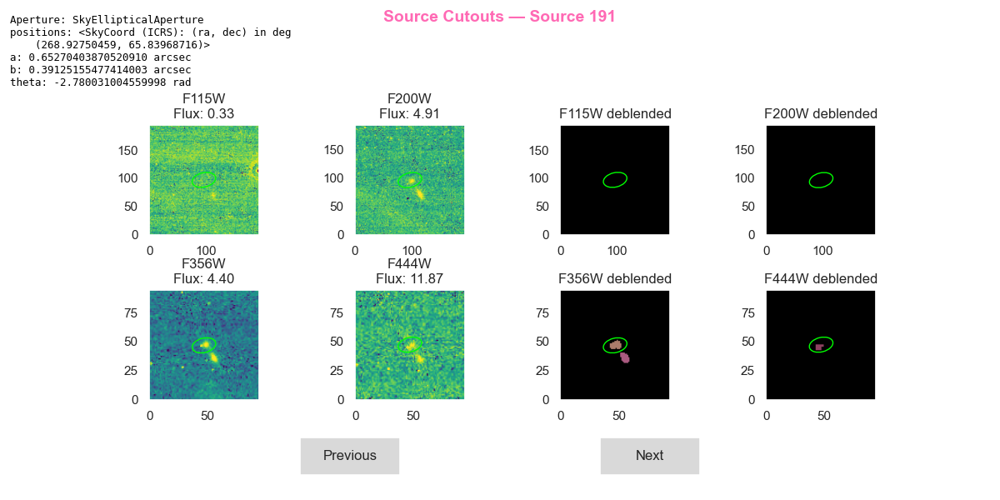

In [279]:
Cutout_Button(acc_cat, i=191)

In [252]:
from matplotlib.gridspec import GridSpec
from matplotlib.widgets import Button
from IPython.display import display, Markdown
import ipywidgets as widgets
from astropy.nddata.utils import Cutout2D
from astropy.visualization import simple_norm
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

def interactive_color_color_viewer(
    scale, ratio_x, ratio_y, accepted_cat, acc_cat_list, im_subbk_list, wcs_list, segm_deblend,
    flux_115, flux_200, flux_356, flux_444, x_label=None, y_label=None,
):
    print(f"Accepted_cat: {len(accepted_cat)}")
    print(f"Ratio_x: {len(ratio_x)}")

    sr_sw = 2.31E-14 #/ Nominal pixel area in steradians 
    sr_lw = 9.34E-14 #/ Nominal pixel area in steradians 

    ratio_x = np.array(ratio_x)
    ratio_y = np.array(ratio_y)
    valid = (ratio_x > 0) & (ratio_y > 0)
    x_valid = ratio_x[valid]
    y_valid = ratio_y[valid]
    indices = np.arange(len(ratio_x))
    valid_indices = indices[valid]

    print(f"Valid_indices: {len(valid_indices)}")

    output = widgets.Output()
    display(output)

    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(3, 2, height_ratios=[1.3, 1, 0.1], hspace=0.35, wspace=0.25)

    ax_top = fig.add_subplot(gs[0, :])
    ax_cut1 = fig.add_subplot(gs[1, 0])
    ax_cut2 = fig.add_subplot(gs[1, 1])
    ax_button_prev = plt.axes([0.25, 0.03, 0.1, 0.05])
    ax_button_next = plt.axes([0.65, 0.03, 0.1, 0.05])

    bnext = Button(ax_button_next, 'Next')
    bprev = Button(ax_button_prev, 'Previous')

    ax_top.scatter(x_valid, y_valid, s=.25, c='black', alpha=0.6)

#if part of non_detection then c='geen' ##Add arrow shape
    
    ax_top.set_xscale(scale)
    ax_top.set_yscale(scale)
    ax_top.set_xlabel(x_label if x_label else 'Flux Ratio X')
    ax_top.set_ylabel(y_label if y_label else 'Flux Ratio Y')
    ax_top.set_title(f"Color-Color Diagram for {x_label} vs. {y_label}")
    ax_top.grid(True)
    ax_top.set_aspect('equal', adjustable='box')

    # State
    state = {
        "idx": valid_indices[0],
        "highlight": None,
    }

    def update(idx):
        state["idx"] = idx
        i = idx

        ap_sky = accepted_cat.kron_aperture[i].to_sky(wcs_list[2])
        sky_pos = ap_sky.positions
        cutout_size = 6 * u.arcsec


        cutout_im = Cutout2D(im_subbk_list[2], sky_pos, cutout_size, wcs=wcs_list[2])
        cutout_segm = Cutout2D(segm_deblend[2], sky_pos, cutout_size, wcs=wcs_list[2])
        aperture_pix = ap_sky.to_pixel(cutout_im.wcs)
    
        norm_im = simple_norm(cutout_im.data, 'asinh', percent=99.5)
        norm_segm = simple_norm(cutout_segm.data, 'asinh', percent=99.5)

        ax_cut1.clear()
        ax_cut2.clear()

        ax_cut1.imshow(cutout_im.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=ax_cut1, color='lime', lw=1)
        ax_cut1.set_title(f"F356W Image — Source {i}")

        ax_cut2.imshow(cutout_segm.data, origin='lower', cmap='nipy_spectral', norm=norm_segm)
        aperture_pix.plot(ax=ax_cut2, color='lime', lw=1)
        ax_cut2.set_title("F356W Segmentation")

        if state["highlight"]:
            state["highlight"].remove()
        i_valid = np.where(valid_indices == i)[0]
        if len(i_valid) > 0:
            j = i_valid[0]
            state["highlight"] = ax_top.plot(x_valid[j], y_valid[j], 'ro', markersize=8)[0]

        fig.canvas.draw_idle()

        with output:
            output.clear_output()
            display(Markdown(f"""
**Catalog index {i}:**
- (x = {x_valid[j]:.3f}, y = {y_valid[j]:.3f})
- F115W = {flux_115[i]:.2f}  
- F200W = {flux_200[i]:.2f}  
- F356W = {flux_356[i]:.2f}  
- F444W = {flux_444[i]:.2f}
"""))

    def on_click(event):
        if event.inaxes != ax_top:
            return
        x_click, y_click = event.xdata, event.ydata
        dist = np.sqrt((x_valid - x_click) ** 2 + (y_valid - y_click) ** 2)
        i_closest = np.argmin(dist)
        new_idx = valid_indices[i_closest]
        update(new_idx)

    def on_next(event):
        current_idx = state["idx"]
        pos = np.where(valid_indices == current_idx)[0][0]
        if pos < len(valid_indices) - 1:
            update(valid_indices[pos + 1])

    def on_prev(event):
        current_idx = state["idx"]
        pos = np.where(valid_indices == current_idx)[0][0]
        if pos > 0:
            update(valid_indices[pos - 1])

    fig.canvas.mpl_connect('button_press_event', on_click)
    bnext.on_clicked(on_next)
    bprev.on_clicked(on_prev)

    index_input = widgets.BoundedIntText(
        value=state["idx"],
        min=0,
        max=len(ratio_x) - 1,
        description='Index:',
        layout=widgets.Layout(width='200px')
    )
    
    go_button = widgets.Button(description="Go", button_style='info')
    
    def on_go_index(event):
        idx = index_input.value
        if idx in valid_indices:
            update(idx)
        else:
            with output:
                output.clear_output(wait=True)
                display(fig)
                display(Markdown(f"❌ Index {idx} not in valid sources.\nTry a number from {valid_indices.min()} to {valid_indices.max()}."))
                
    go_button.on_click(on_go_index)
    display(widgets.HBox([index_input, go_button]))


    update(state["idx"])  # Initial view
    plt.show()


In [135]:
def show_color_color(ratio_x, ratio_y, x_label, y_label, scale):
    interactive_color_color_viewer(
        scale=scale,
        ratio_x=ratio_x, 
        ratio_y=ratio_y,
        accepted_cat=acc_cat,
        acc_cat_list=acc_cat_list,
        im_subbk_list=im_subbk_list,
        wcs_list=wcs_list,
        segm_deblend=segm_deblend,
        flux_115=flux_115,
        flux_200=flux_200,
        flux_356=flux_356,
        flux_444=flux_444,
        x_label=x_label,
        y_label=y_label
    )


In [256]:
len(cat)

2471

Accepted_cat: 1781
Ratio_x: 1781
Valid_indices: 1562


Output()

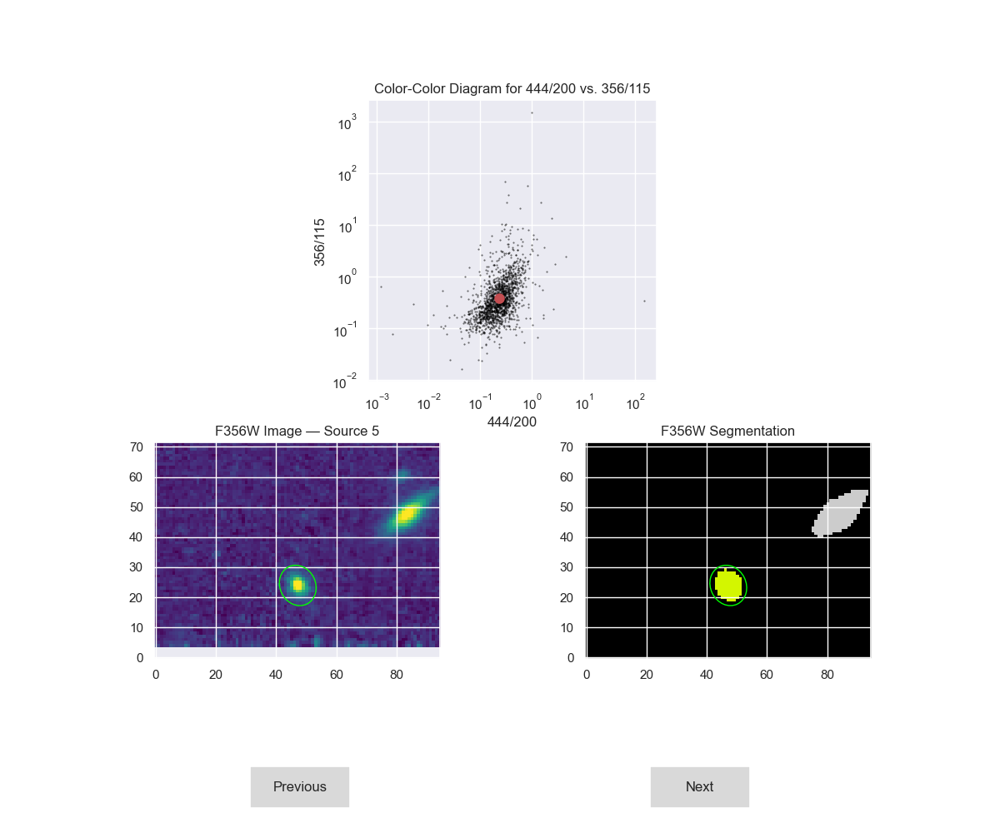

In [255]:
show_color_color(ratio_x=flux_444/flux_200, ratio_y=flux_356/flux_115, x_label = "444/200", y_label="356/115", scale='log')

Accepted_cat: 1781
Ratio_x: 1781
Valid_indices: 1730


Output()

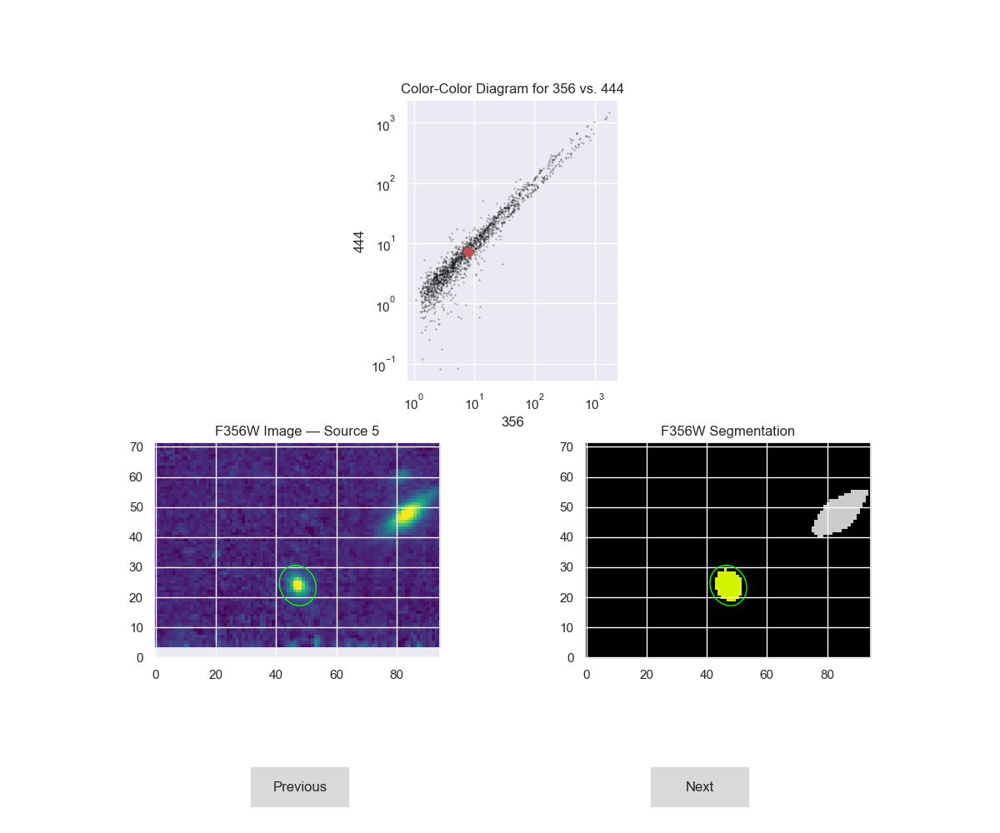

In [219]:
show_color_color(ratio_x=flux_356, ratio_y=flux_444, x_label = "356", y_label="444", scale='log')

In [146]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def plot_sed_from_ratios(df_long, item_number, smooth=True, show=True):
    """
    Plot SED from flux ratios normalized to 356 micron flux.
    
    Parameters:
        df_long: long-format DataFrame with columns ['Item #', 'Flux', 'Ratio']
        item_number: int, ID of item to plot
        smooth: bool, smooth connecting curve
        show: bool, show plot
    """
    data = df_long[df_long["Item #"] == item_number].sort_values("Flux")
    if data.empty or len(data) < 2:
        print(f"Not enough data for Item #{item_number}")
        return
    
    wavelengths_um = data["Flux"].values / 100  # convert to microns
    ratios = data["Ratio"].values
    
    # Filter out zero or negative ratios for log scale
    valid = ratios > 0
    wavelengths_um = wavelengths_um[valid]
    ratios = ratios[valid]
    
    if len(ratios) < 2:
        print(f"Not enough positive ratios for Item #{item_number}")
        return

    log_wl = np.log10(wavelengths_um)
    log_ratios = np.log10(ratios)
    
    # Power-law fit in log-log space
    slope, intercept = np.polyfit(log_wl, log_ratios, 1)
    
    # Smooth curve using spline in log-log space
    if smooth and len(wavelengths_um) >= 3:
        wl_smooth = np.logspace(np.log10(wavelengths_um.min()), np.log10(wavelengths_um.max()), 200)
        spline = make_interp_spline(log_wl, log_ratios, k=3)
        ratios_smooth_log = spline(np.log10(wl_smooth))
        ratios_smooth = 10**ratios_smooth_log
    else:
        wl_smooth = wavelengths_um
        ratios_smooth = ratios

    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(wavelengths_um, ratios, 'o', label='Flux Ratios (normalized to 356 μm)', color='black')
    plt.plot(wl_smooth, ratios_smooth, '-', color='red', label='Smooth SED' if smooth else 'Lines')
    plt.plot(wl_smooth, 10**(intercept + slope * np.log10(wl_smooth)), '--', color='blue', label=f'Power-law fit (slope={slope:.2f})')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Wavelength (μm)')
    plt.ylabel('Flux Ratio (normalized to 356 μm)')
    plt.title(f'SED for Item #{item_number}')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    
    if show:
        plt.show()
    
    return slope, intercept


In [147]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def plot_sed_smooth_with_powerlaw(df_wide, item_number, normalize=True, show=True):
    """
    Plot SED with smooth curve connecting points + power-law fit overlay.

    Parameters:
        df_wide: Original wide-format DataFrame with flux columns like 'flux_115'.
        item_number: int, index of the row to plot.
        normalize: bool, normalize flux by max flux.
        show: bool, whether to plt.show().
    """

    bands = [115, 200, 356, 444]
    wavelengths_um = np.array(bands) / 100

    flux_cols = [f"flux_{b}" for b in bands]
    fluxes = df_wide.loc[item_number, flux_cols].values.astype(float)

    valid = (~np.isnan(fluxes)) & (fluxes > 0)
    if valid.sum() < 3:
        print(f"Not enough valid points (need ≥3) for smooth interpolation for Item #{item_number}.")
        return

    wl_valid = wavelengths_um[valid]
    flux_valid = fluxes[valid]

    if normalize:
        flux_valid = flux_valid / flux_valid.max()

    # Power-law fit in log-log space
    log_wl = np.log10(wl_valid)
    log_flux = np.log10(flux_valid)
    slope, intercept = np.polyfit(log_wl, log_flux, 1)

    # Smooth spline interpolation (for smooth curve between points)
    wl_smooth = np.logspace(np.log10(wl_valid.min()), np.log10(wl_valid.max()), 200)
    spline = make_interp_spline(np.log10(wl_valid), np.log10(flux_valid), k=3)  # cubic spline on log-log
    flux_smooth_log = spline(np.log10(wl_smooth))
    flux_smooth = 10**flux_smooth_log

    # Power-law fit curve
    flux_fit = 10**(intercept + slope * np.log10(wl_smooth))

    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(wl_valid, flux_valid, 'o', color='black', label='Data points')
    plt.plot(wl_smooth, flux_smooth, color='red', label='Smooth spline')
    plt.plot(wl_smooth, flux_fit, '--', color='blue', label=f'Power-law fit (slope={slope:.2f})')

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Wavelength (μm)')
    plt.ylabel('Normalized Flux' if normalize else 'Flux')
    plt.title(f'SED for Item #{item_number}')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    if show:
        plt.show()

    return slope, intercept


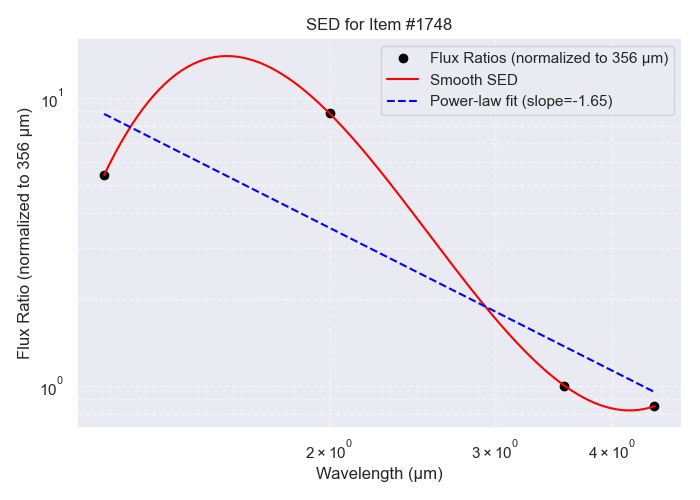

(np.float64(-1.648034106552544), np.float64(1.0448921885154892))

In [148]:
plot_sed_from_ratios(result, item_number=1748)

In [ ]:
plot_sed_smooth_with_powerlaw(fluxes_df, item_number=29)


In [ ]:
plot_sed_from_ratios(result, item_number=29)

In [ ]:
import numpy as np
import pandas as pd

def classify_sources_by_sed_slope(df_long):
    """
    Classifies sources into 'AGN candidate', 'Intermediate / Uncertain', or 'Galaxy'
    based on SED slope (log-log power-law fit).
    
    Parameters:
        df_long: DataFrame in long format with columns ['Item #', 'Flux', 'Ratio']
    
    Returns:
        classified_df: DataFrame with columns ['Item #', 'slope', 'intercept', 'type']
        tables: Dictionary with keys = type, values = filtered DataFrames
    """
    result_list = []

    grouped = df_long.groupby("Item #")
    
    for item, group in grouped:
        group = group.sort_values("Flux")
        fluxes = group["Flux"].values / 100  # convert nm to microns
        ratios = group["Ratio"].values

        # Filter out zero or negative ratios
        valid = ratios > 0
        fluxes = fluxes[valid]
        ratios = ratios[valid]

        if len(ratios) >= 2:
            log_flux = np.log10(fluxes)
            log_ratio = np.log10(ratios)

            slope, intercept = np.polyfit(log_flux, log_ratio, 1)

            if slope <= 0:
                source_type = "AGN candidate"
            elif slope <= 1:
                source_type = "Intermediate / Uncertain"
            else:
                source_type = "Galaxy"

            result_list.append({
                "Item #": item,
                "slope": slope,
                "intercept": intercept,
                "type": source_type
            })

    classified_df = pd.DataFrame(result_list)

    # Separate tables for each type
    tables = {
        "AGN candidate": classified_df[classified_df["type"] == "AGN candidate"],
        "Intermediate / Uncertain": classified_df[classified_df["type"] == "Intermediate / Uncertain"],
        "Galaxy": classified_df[classified_df["type"] == "Galaxy"]
    }

    return classified_df, tables


In [ ]:
classified_df, classified_tables = classify_sources_by_sed_slope(result)


In [ ]:
classified_string = classified_df.to_string(index=False)

In [ ]:
with open('classified_table.txt', 'w') as f:
    f.write(classified_string)

In [ ]:
print(classified_df)

Accepted_cat: 1781
Ratio_x: 1781
Valid_indices: 1730


Output()

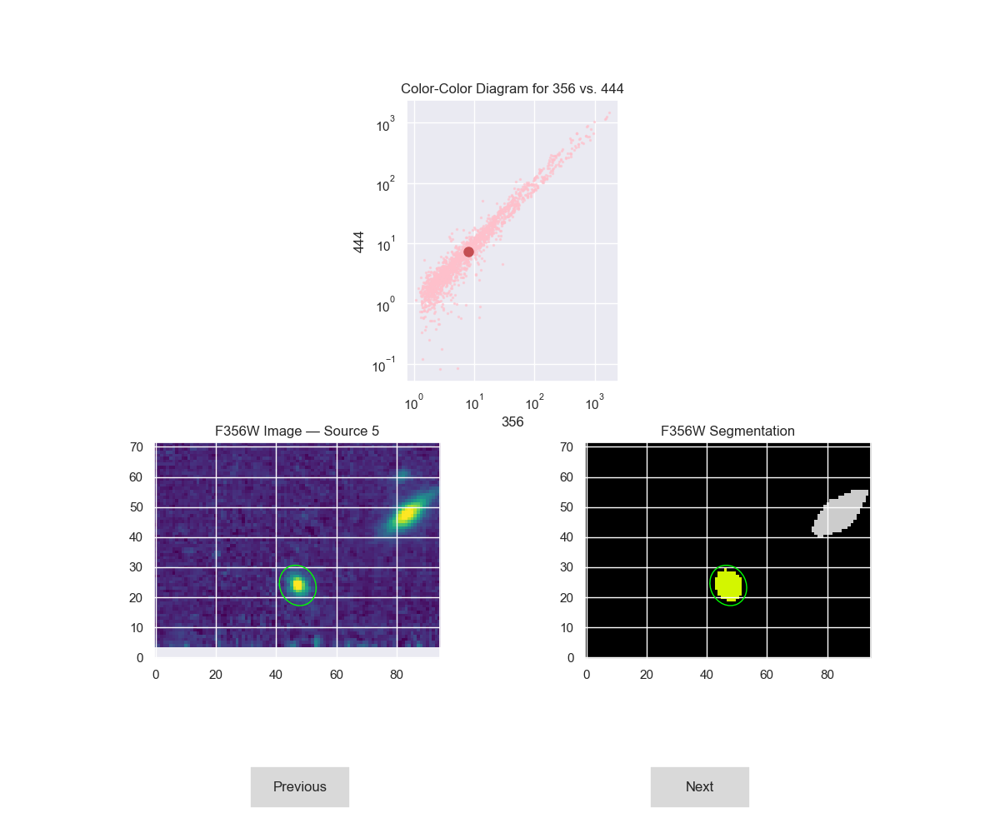

### Attempting to make a histogram of 356/444 vs Frequency

In [139]:
def histogram(flux_ratio, source_1, source_2):

    flux = np.array(flux_ratio)
    flux = flux[flux > 0]
    
    plt.figure(figsize=(8, 5))
    plt.hist(np.log10(flux), bins=100, color='skyblue', edgecolor='black')
    plt.xlabel(f"{source_1}/{source_2}")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {source_1}/{source_2}")
    plt.grid(True)
    plt.show()

In [ ]:
histogram(flux_356/flux_444, "f356W", "f444W")

In [140]:
fluxes_df['115_ratio'] = fluxes_df['flux_115'] / fluxes_df['flux_356']
fluxes_df['200_ratio'] = fluxes_df['flux_200'] / fluxes_df['flux_356']
fluxes_df['356_ratio'] = fluxes_df['flux_356'] / fluxes_df['flux_356']
fluxes_df['444_ratio'] = fluxes_df['flux_444'] / fluxes_df['flux_356']

import seaborn as sns


In [253]:
sns.displot(np.log10(fluxes_df["ratio"]), kde=True, bins=100)

KeyError: 'ratio'

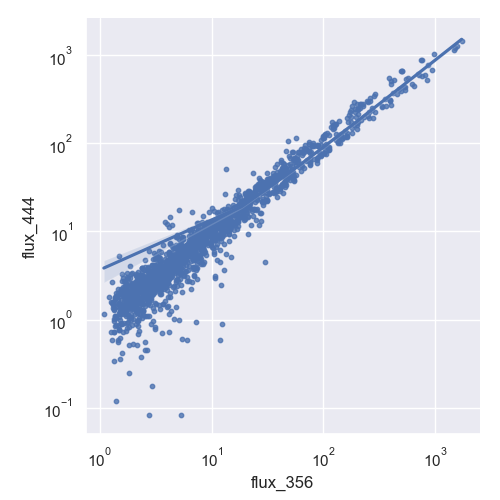

In [254]:
g = sns.lmplot(
    data=fluxes_df,
    x="flux_356", y="flux_444",  scatter_kws={"s": 10})
g.ax.set_yscale('log')
g.ax.set_xscale('log')

In [ ]:
my_table=pd.read_csv('/Users/sshapiro/my_data_fluxes.csv')

In [ ]:
f, axs = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw=dict(width_ratios=[4, 3]))
g = sns.scatterplot(data=fluxes_df, x="flux_356", y="flux_444", ax=axs[0], s=10)
g.set(xscale="log", yscale="log")
sns.histplot(np.log10(fluxes_df["ratio"]), kde=True, bins=100, ax=axs[1])
f.tight_layout()

### Using NED

In [ ]:
from astroquery.ned import Ned
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
import time

def query_ned_for_catalog(cat, radius_arcsec=2.0, delay=1.0):
    """
    Query NED for all sources in catalog and return a table of matched sources.
    
    Parameters:
    - cat: Astropy Table with 'ra' and 'dec' columns (in degrees)
    - radius_arcsec: Search radius for NED crossmatch
    - delay: Time to wait between queries to avoid rate-limiting
    
    Returns:
    - Astropy Table with matched sources
    """
    matched = []

    for i, row in enumerate(cat):
        ra = row['ra']
        dec = row['dec']
        coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')

        try:
            ned_result = Ned.query_region(coord, radius=radius_arcsec * u.arcsec)

            if len(ned_result) > 0:
                for obj in ned_result:
                    matched.append({
                        "source_index": i,
                        "ra": ra,
                        "dec": dec,
                        "ned_name": obj.get("Object Name", None),
                        "ned_type": obj.get("Type", None),
                        "redshift": obj.get("Redshift", None),
                        "magnitude_b": obj.get("Magnitude B", None)
                    })
        except Exception as e:
            print(f"Error querying source {i} (RA={ra}, Dec={dec}): {e}")
        
        time.sleep(delay)  # be nice to NED’s servers
    
    return Table(rows=matched)


In [ ]:
#test_tbl=tbl[:2471]
#ned_matches = query_ned_for_catalog(test_tbl)  # This uses the function we made earlier
#ned_matches.pprint(max_lines=10)


In [ ]:
len(acc_cat)

In [ ]:
len(acc_cat)

In [ ]:
#accepted_tbl=acc_tbl[:1781]
#acc_ned_matches = query_ned_for_catalog(accepted_tbl)

In [ ]:
#print(acc_ned_matches)

In [ ]:
#acc_ned_matches.write("acc_ned_matches_table_1.txt", format="ascii.fixed_width", overwrite=True)


In [ ]:
#acc_ned_matches_with_index = acc_ned_matches
#acc_ned_matches_with_index.add_column(np.arange(len(acc_ned_matches)), name='Row', index=0)
#acc_ned_matches_with_index.write("acc_ned_matches_table_1.txt", format="ascii.fixed_width", overwrite=True)


In [222]:
from astroquery.simbad import Simbad
from astropy.coordinates import SkyCoord
import astropy.units as u

def query_simbad_for_catalog(cat):
    size = 2 # arsec
    search = (size *u.arcsec).to(u.deg) # the search radius is in deg. 
    simbad = Simbad()
# let's add type of source and redshift to the SIMBAD query
    simbad.add_votable_fields("otype", "otypedef","rvz_redshift")

    matched = []
    
    for i, row in enumerate(cat):
        ra = row['ra']
        dec = row['dec']
        coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')
        #co = coordinates.SkyCoord(ra=RA, dec=DEC, unit=(u.deg, u.deg))

        try:
            simbad_result = simbad.query_region(coord, radius=search)

            if simbad_result is not None and len(simbad_result) > 0:
                for obj in simbad_result:
                    matched.append({
                    'source_index': i,
                    'ra': ra,
                    'dec': dec,
                    'simbad_name': obj.get("Object Name", None),
                    'simbad_type': obj.get("Type", None),
                    'simbad_redshift': obj.get("Redshift", None)
                    })

        except Exception as e:
                    print(f"Error querying source {i} (RA={ra}, Dec={dec}): {e}")
                    matched.append({
                        'source_index': i,
                        'ra': ra,
                        'dec': dec,
                        'simbad_name': None,
                        'simbad_type': None,
                        'simbad_redshift': None
                    })

    return Table(rows=matched)
                    

In [223]:
accepted_tbl=acc_tbl[:1781]
acc_simbad_matches = query_simbad_for_catalog(accepted_tbl)

KeyboardInterrupt: 

In [ ]:
#ned_matches=pd.read_csv(
    # Assuming your data is separated by a specific delimiter (e.g., comma, tab, space)
ned_matches = Table.read("acc_ned_matches_table.txt", format="ascii.fixed_width")

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.widgets import Button
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
from astropy.coordinates import SkyCoord
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import ipywidgets as widgets

def interactive_astroquery():
    ra = ned_matches['ra']
    dec = ned_matches['dec']
    ned_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    output = widgets.Output()
    display(output)

    # Figure and axes
    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(3, 2, height_ratios=[1.3, 1, 0.1], hspace=0.35, wspace=0.25)

    ax_top = fig.add_subplot(gs[0, :])
    ax_cut1 = fig.add_subplot(gs[1, 0])
    ax_cut2 = fig.add_subplot(gs[1, 1])
    ax_button_prev = plt.axes([0.25, 0.03, 0.1, 0.05])
    ax_button_next = plt.axes([0.65, 0.03, 0.1, 0.05])

    bnext = Button(ax_button_next, 'Next')
    bprev = Button(ax_button_prev, 'Previous')

    ax_top.scatter(ra, dec, s=20, c='blue', label="NED matches")
    ax_top.set_xlabel("RA (deg)")
    ax_top.set_ylabel("Dec (deg)")
    ax_top.set_title("NED Sources")
    ax_top.invert_xaxis()
    ax_top.grid(True)

    # State
    state = {
        "ned_idx": 0,
        "highlight": None,
    }

    def update(ned_idx):
        if ned_idx < 0 or ned_idx >= len(ned_matches):
            return
        state["ned_idx"] = ned_idx

        label = ned_matches['source_index'][ned_idx]
        row_matches = np.where(acc_cat.labels == label)[0]

        if len(row_matches) == 0:
            print(f"Label {label} not found in catalog!")
            return

        row_num = row_matches[0]


        # Use fixed image index unless you later make this dynamic
        image_idx = 2  
        ap_sky = acc_cat.kron_aperture[row_num].to_sky(wcs_list[image_idx])
        sky_pos = ap_sky.positions
        cutout_size = 6 * u.arcsec

        cutout_im = Cutout2D(im_subbk_list[image_idx], sky_pos, cutout_size, wcs=wcs_list[image_idx])
        cutout_segm = Cutout2D(segm_deblend[image_idx], sky_pos, cutout_size, wcs=wcs_list[image_idx])
        aperture_pix = ap_sky.to_pixel(cutout_im.wcs)

        norm_im = simple_norm(cutout_im.data, 'asinh', percent=99.5)
        norm_segm = simple_norm(cutout_segm.data, 'asinh', percent=99.5)

        ax_cut1.clear()
        ax_cut2.clear()

        ax_cut1.imshow(cutout_im.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=ax_cut1, color='lime', lw=1)
        ax_cut1.set_title(f"F356W Image — Label {label}")

        ax_cut2.imshow(cutout_segm.data, origin='lower', cmap='nipy_spectral', norm=norm_segm)
        aperture_pix.plot(ax=ax_cut2, color='lime', lw=1)
        ax_cut2.set_title("Segmentation")

        if state["highlight"]:
            state["highlight"].remove()
        state["highlight"] = ax_top.plot(ra[ned_idx], dec[ned_idx], 'ro', markersize=8)[0]

        fig.canvas.draw_idle()

        with output:
            output.clear_output()
            display(Markdown(f"""
**Selected source label `{label}`:**
- RA: {ra[ned_idx]:.5f}, Dec: {dec[ned_idx]:.5f}
- NED Name: {ned_matches['ned_name'][ned_idx]}
- Type: {ned_matches['ned_type'][ned_idx]}
- Redshift: {ned_matches['redshift'][ned_idx]}
"""))

    def on_click(event):
        if event.inaxes != ax_top:
            return
        if event.xdata is None or event.ydata is None:
            return

        click_coord = SkyCoord(ra=event.xdata * u.deg, dec=event.ydata * u.deg)
        sep = click_coord.separation(ned_coords)
        ned_idx_closest = np.argmin(sep)
        update(ned_idx_closest)

    def on_next(event):
        current_idx = state["ned_idx"]
        if current_idx < len(ned_matches) - 1:
            update(current_idx + 1)

    def on_prev(event):
        current_idx = state["ned_idx"]
        if current_idx > 0:
            update(current_idx - 1)

    fig.canvas.mpl_connect('button_press_event', on_click)
    bnext.on_clicked(on_next)
    bprev.on_clicked(on_prev)

    update(0)
    plt.show()


In [ ]:
len(ned_matches)

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.widgets import Button
from astropy.nddata import Cutout2D
from astropy.visualization import simple_norm
from astropy.coordinates import SkyCoord
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import ipywidgets as widgets

def interactive_astroquery():
    ra = ned_matches['ra']
    dec = ned_matches['dec']
    ned_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)

    output = widgets.Output()
    display(output)

    # --- Search UI ---
    search_value_input = widgets.Text(description='Search:')
    search_field_dropdown = widgets.Dropdown(
        options=['index', 'ned_name', 'ned_type', 'redshift'],
        description='Field:'
    )
    search_button = widgets.Button(description='Search')
    display(widgets.HBox([search_value_input, search_field_dropdown, search_button]))

    # --- Plot setup ---
    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(3, 2, height_ratios=[1.3, 1, 0.1], hspace=0.35, wspace=0.25)

    ax_top = fig.add_subplot(gs[0, :])
    ax_cut1 = fig.add_subplot(gs[1, 0])
    ax_cut2 = fig.add_subplot(gs[1, 1])
    ax_button_prev = plt.axes([0.25, 0.03, 0.1, 0.05])
    ax_button_next = plt.axes([0.65, 0.03, 0.1, 0.05])

    bnext = Button(ax_button_next, 'Next')
    bprev = Button(ax_button_prev, 'Previous')

    ax_top.scatter(ra, dec, s=20, c='blue', label="NED matches")
    ax_top.set_xlabel("RA (deg)")
    ax_top.set_ylabel("Dec (deg)")
    ax_top.set_title("NED Sources")
    ax_top.invert_xaxis()
    ax_top.grid(True)

    # --- Viewer state ---
    state = {
        "ned_idx": 0,
        "highlight": None,
    }

    def update(ned_idx):
        if ned_idx < 0 or ned_idx >= len(ned_matches):
            return
        state["ned_idx"] = ned_idx

        label = ned_matches['source_index'][ned_idx]
        row_matches = np.where(acc_cat.labels == label)[0]

        if len(row_matches) == 0:
            print(f"Label {label} not found in acc_cat!")
            return

        row_num = row_matches[0]
        image_idx = 2  # Change as needed

        ap_sky = acc_cat.kron_aperture[row_num].to_sky(wcs_list[image_idx])
        sky_pos = ap_sky.positions
        cutout_size = 6 * u.arcsec

        cutout_im = Cutout2D(im_subbk_list[image_idx], sky_pos, cutout_size, wcs=wcs_list[image_idx])
        cutout_segm = Cutout2D(segm_deblend[image_idx], sky_pos, cutout_size, wcs=wcs_list[image_idx])
        aperture_pix = ap_sky.to_pixel(cutout_im.wcs)

        norm_im = simple_norm(cutout_im.data, 'asinh', percent=99.5)
        norm_segm = simple_norm(cutout_segm.data, 'asinh', percent=99.5)

        ax_cut1.clear()
        ax_cut2.clear()

        ax_cut1.imshow(cutout_im.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=ax_cut1, color='lime', lw=1)
        ax_cut1.set_title(f"F356W Image — Label {label}")

        ax_cut2.imshow(cutout_segm.data, origin='lower', cmap='nipy_spectral', norm=norm_segm)
        aperture_pix.plot(ax=ax_cut2, color='lime', lw=1)
        ax_cut2.set_title("Segmentation")

        if state["highlight"]:
            state["highlight"].remove()
        state["highlight"] = ax_top.plot(ra[ned_idx], dec[ned_idx], 'ro', markersize=8)[0]

        fig.canvas.draw_idle()

        with output:
            output.clear_output()
            display(Markdown(f"""
**Selected NED source label `{label}`:**
- RA: {ra[ned_idx]:.5f}, Dec: {dec[ned_idx]:.5f}
- NED Name: {ned_matches['ned_name'][ned_idx]}
- Type: {ned_matches['ned_type'][ned_idx]}
- Redshift: {ned_matches['redshift'][ned_idx]}
"""))

    def on_click(event):
        if event.inaxes != ax_top:
            return
        if event.xdata is None or event.ydata is None:
            return

        click_coord = SkyCoord(ra=event.xdata * u.deg, dec=event.ydata * u.deg)
        sep = click_coord.separation(ned_coords)
        ned_idx_closest = np.argmin(sep)
        update(ned_idx_closest)

    def on_next(event):
        current_idx = state["ned_idx"]
        if current_idx < len(ned_matches) - 1:
            update(current_idx + 1)

    def on_prev(event):
        current_idx = state["ned_idx"]
        if current_idx > 0:
            update(current_idx - 1)

    def on_search_clicked(b):
        field = search_field_dropdown.value
        query = search_value_input.value.strip()

        if field == 'index':
            try:
                idx = int(query)
                if 0 <= idx < len(ned_matches):
                    update(idx)
                else:
                    print(f"Index {idx} out of range.")
            except ValueError:
                print("Please enter a valid integer index.")
            return

        try:
            # Numeric fields: float matching with tolerance
            if ned_matches[field].dtype.kind in ['i', 'f']:
                query_val = float(query)
                match_indices = np.where(np.isclose(ned_matches[field], query_val, atol=1e-4))[0]
            else:
                # String exact match; consider lower() for case-insensitive later
                match_indices = np.where(ned_matches[field] == query)[0]
        except Exception as e:
            print(f"Search error: {e}")
            return

        if len(match_indices) == 0:
            print(f"No matches for {field} = '{query}'")
            return

        ned_idx = match_indices[0]
        update(ned_idx)

    # --- Connect events ---
    fig.canvas.mpl_connect('button_press_event', on_click)
    bnext.on_clicked(on_next)
    bprev.on_clicked(on_prev)
    search_button.on_click(on_search_clicked)

    update(0)
    plt.show()


In [ ]:
interactive_astroquery()

In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# cat is your SourceCatalog, wcs is your WCS
coords = cat.sky_centroid_icrs  # Already a SkyCoord object


In [ ]:
show_color_color(ratio_x=flux_115/flux_356, ratio_y=flux_444/flux_356, x_label = "115/356", y_label="444/356", scale='log')

In [ ]:
class AstroqueryViewer:
    def __init__(self, cat):
        self.cat = cat
        self.ra = ned_matches['ra']
        self.dec = ned_matches['dec']
        self.coords = SkyCoord(ra=self.ra * u.deg, dec=self.dec * u.deg)
        self.index = 0
        self.highlight = None

        # Setup output and manual input widgets
        self.output = widgets.Output()
        self.index_input = widgets.IntText(
            value=0, description='Go to:', min=0, max=len(ned_matches) - 1
        )
        self.go_button = widgets.Button(description="Update")

        self.go_button.on_click(self.on_go_index)
        display(widgets.HBox([self.index_input, self.go_button]))
        display(self.output)

        self.fig = plt.figure(figsize=(8, 6))
        gs = GridSpec(3, 2, height_ratios=[1.3, 1, 0.1], hspace=0.35, wspace=0.25)

        self.ax_top = self.fig.add_subplot(gs[0, :])
        self.ax_cut1 = self.fig.add_subplot(gs[1, 0])
        self.ax_cut2 = self.fig.add_subplot(gs[1, 1])
        ax_button_prev = plt.axes([0.25, 0.03, 0.1, 0.05])
        ax_button_next = plt.axes([0.65, 0.03, 0.1, 0.05])

        self.bnext = Button(ax_button_next, 'Next')
        self.bprev = Button(ax_button_prev, 'Previous')
        self.bnext.on_clicked(self.on_next)
        self.bprev.on_clicked(self.on_prev)

        self.ax_top.scatter(self.ra, self.dec, s=20, c='blue', label="NED matches")
        self.ax_top.set_xlabel("RA (deg)")
        self.ax_top.set_ylabel("Dec (deg)")
        self.ax_top.set_title("NED Sources")
        self.ax_top.invert_xaxis()
        self.ax_top.grid(True)

        self.fig.canvas.mpl_connect('button_press_event', self.on_click)

        self.update()
        plt.show()

    def update(self):
        idx = self.index
        source_i = ned_matches['source_index'][idx]

        ap_sky = self.cat.kron_aperture[source_i].to_sky(wcs_list[2])
        sky_pos = ap_sky.positions
        cutout_size = 6 * u.arcsec

        cutout_im = Cutout2D(im_subbk_list[2], sky_pos, cutout_size, wcs=wcs_list[2])
        cutout_segm = Cutout2D(segm_deblend[2], sky_pos, cutout_size, wcs=wcs_list[2])
        aperture_pix = ap_sky.to_pixel(cutout_im.wcs)

        norm_im = simple_norm(cutout_im.data, 'asinh', percent=99.5)
        norm_segm = simple_norm(cutout_segm.data, 'asinh', percent=99.5)

        self.ax_cut1.clear()
        self.ax_cut2.clear()

        self.ax_cut1.imshow(cutout_im.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=self.ax_cut1, color='lime', lw=1)
        self.ax_cut1.set_title(f"F356W Image — Source {source_i}")

        self.ax_cut2.imshow(cutout_segm.data, origin='lower', cmap='nipy_spectral', norm=norm_segm)
        aperture_pix.plot(ax=self.ax_cut2, color='lime', lw=1)
        self.ax_cut2.set_title("Segmentation")

        if self.highlight:
            self.highlight.remove()
        self.highlight = self.ax_top.plot(self.ra[idx], self.dec[idx], 'ro', markersize=8)[0]

        self.fig.canvas.draw_idle()

        with self.output:
            self.output.clear_output()
            display(Markdown(f"""
**Selected source index {source_i}:**
- RA: {self.ra[idx]:.5f}, Dec: {self.dec[idx]:.5f}
- NED Name: {ned_matches['ned_name'][idx]}
- Type: {ned_matches['ned_type'][idx]}
- Redshift: {ned_matches['redshift'][idx]}
"""))

    def on_click(self, event):
        if event.inaxes != self.ax_top:
            return
        if event.xdata is None or event.ydata is None:
            return
        click_coord = SkyCoord(ra=event.xdata * u.deg, dec=event.ydata * u.deg)
        sep = click_coord.separation(self.coords)
        closest_idx = np.argmin(sep)
        self.index = closest_idx
        self.index_input.value = closest_idx
        self.update()

    def on_next(self, event):
        if self.index < len(ned_matches) - 1:
            self.index += 1
            self.index_input.value = self.index
            self.update()

    def on_prev(self, event):
        if self.index > 0:
            self.index -= 1
            self.index_input.value = self.index
            self.update()

    def on_go_index(self, event):
        idx = self.index_input.value
        idx = max(0, min(len(ned_matches) - 1, idx))  # Clamp
        self.index = idx
        self.update()


In [ ]:
viewer = AstroqueryViewer(acc_cat)


In [ ]:
plot_source_cutouts(acc_cat, i=1725)

In [ ]:
plot_source_cutouts(acc_cat, i=15)

In [ ]:
def color_color_designated_cutout(
    x_axis, y_axis, ratio_x, ratio_y, cat, cat_list, im_subbk_list, wcs_list, segm_deblend,
    flux_115, flux_200, flux_356, flux_444, x_label=None, y_label=None
):
    ratio_x = np.array(ratio_x)
    ratio_y = np.array(ratio_y)
    valid = (ratio_x > 0) & (ratio_y > 0)
    x_valid = ratio_x[valid]
    y_valid = ratio_y[valid]
    indices = np.arange(len(ratio_x))
    valid_indices = indices[valid]

    output = widgets.Output()
    display(output)

    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(3, 2, height_ratios=[1.3, 1, 0.1], hspace=0.35, wspace=0.25)

    ax_top = fig.add_subplot(gs[0, :])
    ax_cut1 = fig.add_subplot(gs[1, 0])
    ax_cut2 = fig.add_subplot(gs[1, 1])
    ax_button_prev = plt.axes([0.25, 0.03, 0.1, 0.05])
    ax_button_next = plt.axes([0.65, 0.03, 0.1, 0.05])

    bnext = Button(ax_button_next, 'Next')
    bprev = Button(ax_button_prev, 'Previous')

    ax_top.scatter(x_valid, y_valid, s=10, c='blue', alpha=0.6)
    ax_top.set_xscale('log')
    ax_top.set_yscale('log')
    ax_top.set_xlabel(x_label if x_label else 'Flux Ratio X')
    ax_top.set_ylabel(y_label if y_label else 'Flux Ratio Y')
    ax_top.set_title(f"Color-Color Diagram for {x_label} vs. {y_label}")
    ax_top.grid(True)
    ax_top.set_aspect('equal', adjustable='box')

    # State
    state = {
        "idx": valid_indices[0],
        "highlight": None,
    }

    def update(idx):
        state["idx"] = idx
        i = idx

        ap_sky = cat.kron_aperture[i].to_sky(wcs_list[2])
        sky_pos = ap_sky.positions
        cutout_size = 6 * u.arcsec

        bkg_1 =  Background2D(x_axis['SCI'].data, (200,200), filter_size=(3,3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
        im_1 = x_axis['SCI'].data - bkg_1.background
        
        bkg_2 =  Background2D(y_axis['SCI'].data, (200,200), filter_size=(3,3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)
        im_2 = y_axis['SCI'].data - bkg_2.background

        cutout_im1 = Cutout2D(im_1, sky_pos, cutout_size, wcs=wcs_list[2])
        cutout_im2 = Cutout2D(im_2, sky_pos, cutout_size, wcs=wcs_list[2])
        aperture_pix = ap_sky.to_pixel(cutout_im1.wcs)
    
        norm_im = simple_norm(cutout_im1.data, 'asinh', percent=99.5)

        ax_cut1.clear()
        ax_cut2.clear()

        ax_cut1.imshow(cutout_im1.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=ax_cut1, color='lime', lw=1)
        ax_cut1.set_title(f"{x_label} Cutout")

        ax_cut2.imshow(cutout_im2.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=ax_cut2, color='lime', lw=1)
        ax_cut2.set_title(f"{y_label} Cutout")

        if state["highlight"]:
            state["highlight"].remove()
        i_valid = np.where(valid_indices == i)[0]
        if len(i_valid) > 0:
            j = i_valid[0]
            state["highlight"] = ax_top.plot(x_valid[j], y_valid[j], 'ro', markersize=8)[0]

        fig.canvas.draw_idle()

        with output:
            output.clear_output()
            display(Markdown(f"""
**Catalog index {i}:**
- (x = {x_valid[j]:.3f}, y = {y_valid[j]:.3f})
- F115W = {flux_115[i]:.2f}  
- F200W = {flux_200[i]:.2f}  
- F356W = {flux_356[i]:.2f}  
- F444W = {flux_444[i]:.2f}
"""))

    def on_click(event):
        if event.inaxes != ax_top:
            return
        x_click, y_click = event.xdata, event.ydata
        dist = np.sqrt((x_valid - x_click) ** 2 + (y_valid - y_click) ** 2)
        i_closest = np.argmin(dist)
        new_idx = valid_indices[i_closest]
        update(new_idx)

    def on_next(event):
        current_idx = state["idx"]
        pos = np.where(valid_indices == current_idx)[0][0]
        if pos < len(valid_indices) - 1:
            update(valid_indices[pos + 1])

    def on_prev(event):
        current_idx = state["idx"]
        pos = np.where(valid_indices == current_idx)[0][0]
        if pos > 0:
            update(valid_indices[pos - 1])

    def on_go_index(self, event):
        idx = self.index_input.value
        idx = max(0, min(len(ned_matches) - 1, idx))  # Clamp
        self.index = idx
        self.update()

    fig.canvas.mpl_connect('button_press_event', on_click)
    bnext.on_clicked(on_next)
    bprev.on_clicked(on_prev)

    update(state["idx"])  # Initial view
    plt.show()


In [ ]:
def show_color(x_axis, y_axis, ratio_x, ratio_y, x_label, y_label):
    color_color_designated_cutout(
        x_axis = x_axis,
        y_axis = y_axis,
        ratio_x=ratio_x, 
        ratio_y=ratio_y,
        cat=acc_cat,
        cat_list=acc_cat_list,
        im_subbk_list=im_subbk_list,
        wcs_list=wcs_list,
        segm_deblend=segm_deblend,
        flux_115=flux_115,
        flux_200=flux_200,
        flux_356=flux_356,
        flux_444=flux_444,
        x_label=x_label,
        y_label=y_label
    )


In [ ]:
show_color(x_axis=f115w, y_axis=f444w, ratio_x = flux_115, ratio_y = flux_444, x_label=115, y_label=444)

In [ ]:
## Marcio wants me to make the 115 nondetections NaN values so they don't mess up our values.. I'm unsure how to approach this

## If value<0 make it NaN??

In [170]:
import matplotlib.pyplot as plt

def plot_all_seds(df_long):
    plt.figure(figsize=(10, 6))

    # Convert Flux from nm to microns
    df_long["micron"] = df_long["Flux"] / 1000

    # Plot each source as a line (or scatter if you prefer)
    for item, group in df_long.groupby("Item #"):
        valid = group["Ratio"] > 0
        plt.plot(group.loc[valid, "micron"], group.loc[valid, "Ratio"], 
                 alpha=0.2, linewidth=0.8)
        #plt.scatter(group.loc[valid, "micron"], group.loc[valid, "Ratio"], alpha=0.1, s=5)


    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Normalized Flux (Flux / Flux_356)")
    plt.title("SEDs of All Sources")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


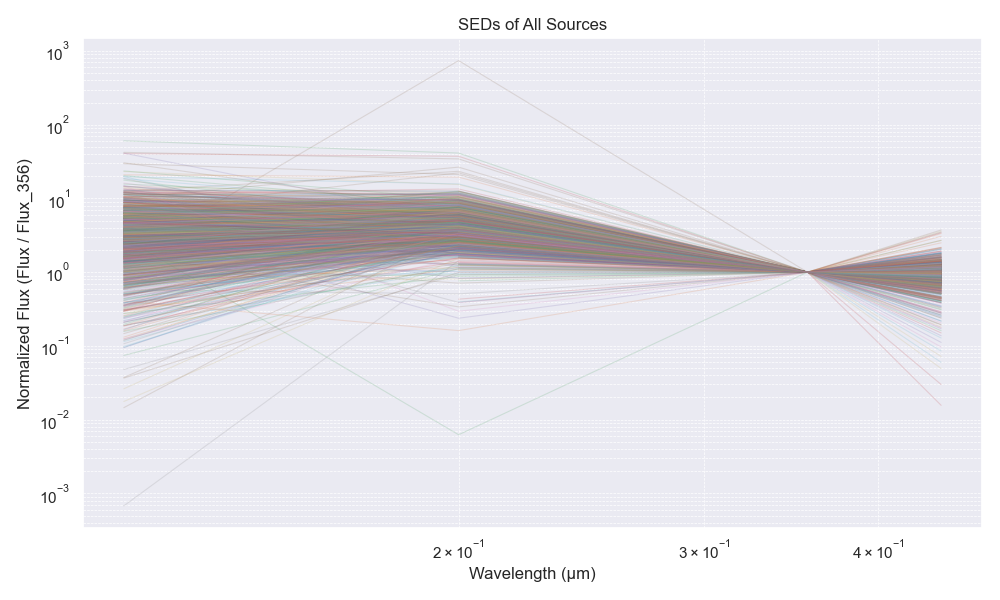

In [171]:
plot_all_seds(result)


In [159]:

import matplotlib.pyplot as plt

def plot_all_seds_unormalized(df):
    # Define wavelengths and their corresponding column names
    band_dict = {
        1.15: 'flux_115',
        2.00: 'flux_200',
        3.56: 'flux_356',
        4.44: 'flux_444'
    }

    # Melt the DataFrame into long format
    long_df = pd.melt(
        df.reset_index(),
        id_vars=['index'],  # index is used as source ID
        value_vars=band_dict.values(),
        var_name='Band',
        value_name='Flux'
    )

    # Extract wavelength in microns from column names
    band_map = {v: k for k, v in band_dict.items()}
    long_df['Wavelength (μm)'] = long_df['Band'].map(band_map)
    long_df.rename(columns={'index': 'Item #'}, inplace=True)

    # Filter out invalid fluxes
    long_df = long_df[long_df['Flux'] > 0]

    # Plot all SEDs
    plt.figure(figsize=(10, 6))
    for item, group in long_df.groupby("Item #"):
        plt.plot(group["Wavelength (μm)"], group["Flux"], alpha=0.2, linewidth=0.8)

    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Flux")
    plt.title("Unnormalized SEDs of All Sources")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


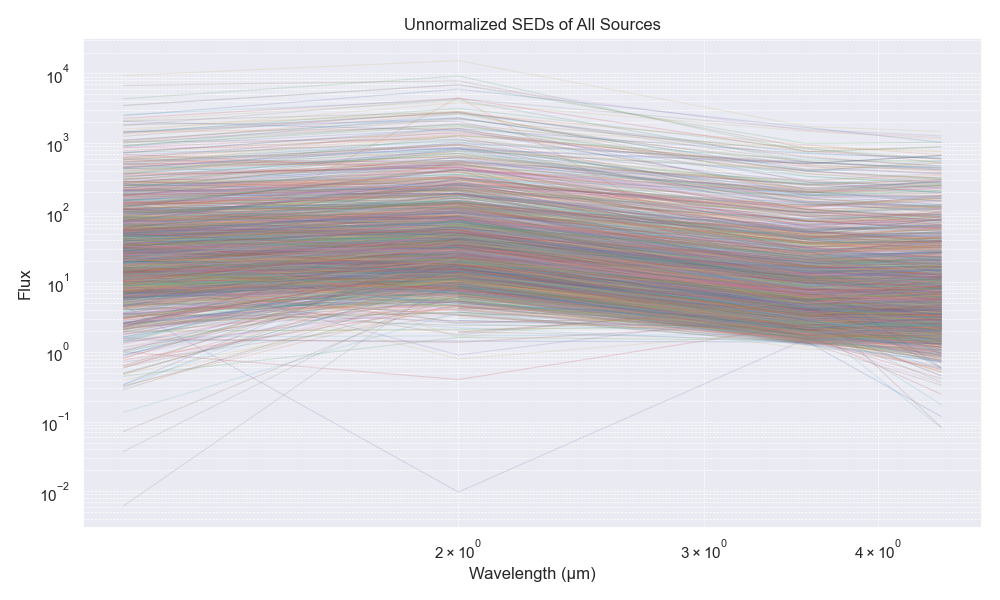

In [161]:
plot_all_seds_unormalized(fluxes_df)

In [178]:
import pandas as pd
import matplotlib.pyplot as plt

def scatter_all_seds_unnormalized(df):
    # Define wavelengths in microns and their column names
    band_dict = {
        1.15: 'flux_115',
        2.00: 'flux_200',
        3.56: 'flux_356',
        4.44: 'flux_444'
    }

    # Convert wide to long format
    long_df = pd.melt(
        df.reset_index(),
        id_vars=['index'],  # treat row index as source ID
        value_vars=band_dict.values(),
        var_name='Band',
        value_name='Flux'
    )

    # Map band names to wavelengths in microns
    band_map = {v: k for k, v in band_dict.items()}
    long_df['Wavelength (μm)'] = long_df['Band'].map(band_map)
    long_df.rename(columns={'index': 'Item #'}, inplace=True)

    # Remove invalid fluxes
    long_df = long_df[long_df['Flux'] > 0]

    # Plot as scatter
    plt.figure(figsize=(10, 6))
    plt.scatter(long_df['Wavelength (μm)'], long_df['Flux'], 
                alpha=0.15, s=10, c='black')

    plt.xlabel("Wavelength (μm)")
    plt.ylabel("Flux")
    plt.title("Scatter Plot of Unnormalized SEDs")
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    plt.show()


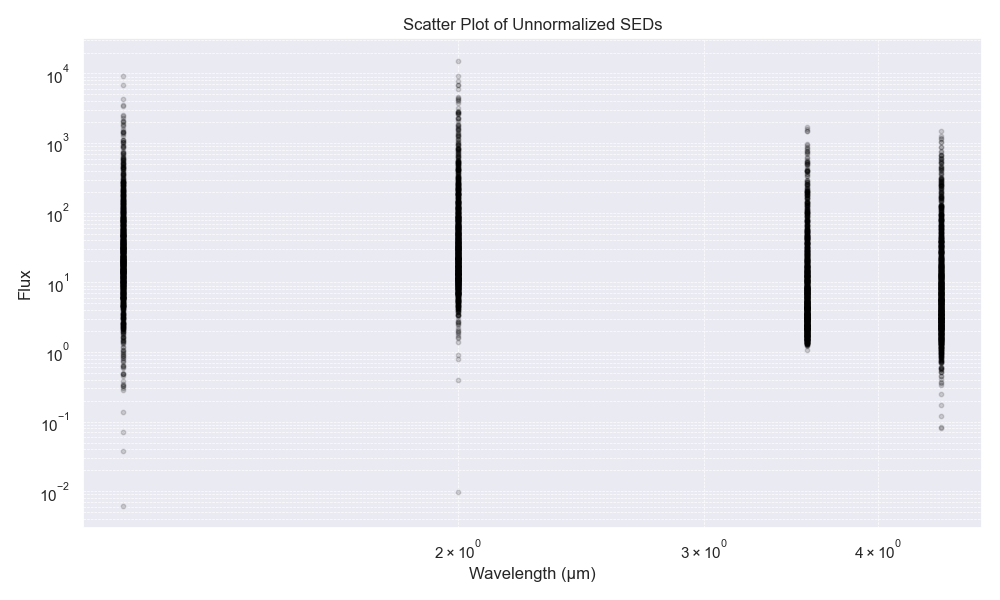

In [179]:
scatter_all_seds_unnormalized(fluxes_df)


In [189]:
from matplotlib.gridspec import GridSpec
from matplotlib.widgets import Button
from IPython.display import display, Markdown
import ipywidgets as widgets
from astropy.nddata.utils import Cutout2D
from astropy.visualization import simple_norm
import numpy as np
import matplotlib.pyplot as plt


def interactive_sed_viewer(
    accepted_cat, acc_cat_list, im_subbk_list, wcs_list, segm_deblend,
    flux_115, flux_200, flux_356, flux_444,
    ratio_115, ratio_200, ratio_356, ratio_444
):
    output = widgets.Output()
    display(output)

    # Wavelengths in microns
    wavelengths_micron = np.array([1.15, 2.00, 3.56, 4.44])
    all_ratios = np.vstack([ratio_115, ratio_200, ratio_356, ratio_444]).T

    valid_sources = ~np.isnan(all_ratios).any(axis=1)
    valid_indices = np.where(valid_sources)[0]

    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(3, 2, height_ratios=[1.3, 1, 0.1], hspace=0.35, wspace=0.25)

    ax_top = fig.add_subplot(gs[0, :])
    ax_cut1 = fig.add_subplot(gs[1, 0])
    ax_cut2 = fig.add_subplot(gs[1, 1])
    ax_button_prev = plt.axes([0.25, 0.03, 0.1, 0.05])
    ax_button_next = plt.axes([0.65, 0.03, 0.1, 0.05])

    bnext = Button(ax_button_next, 'Next')
    bprev = Button(ax_button_prev, 'Previous')

    # Plot all sources as scatter plots
    for i in valid_indices:
        ratios = all_ratios[i]
        color = plt.cm.tab20(i % 20)
        ax_top.scatter(wavelengths_micron, ratios, color=color, s=20, alpha=0.5)

    ax_top.set_xlabel("Wavelength (micron)")
    ax_top.set_ylabel("Normalized Flux (Ratio to F356W)")
    ax_top.set_title("Interactive Normalized SED Viewer")
    ax_top.set_xscale("log")
    ax_top.set_yscale("log")
    ax_top.grid(True)

    state = {
        "idx": valid_indices[0],
        "highlight": None,
    }

    def update(idx):
        state["idx"] = idx
        i = idx

        # Update cutouts
        ap_sky = accepted_cat.kron_aperture[i].to_sky(wcs_list[2])
        sky_pos = ap_sky.positions
        cutout_size = 6 * u.arcsec

        cutout_im = Cutout2D(im_subbk_list[2], sky_pos, cutout_size, wcs=wcs_list[2])
        cutout_segm = Cutout2D(segm_deblend[2], sky_pos, cutout_size, wcs=wcs_list[2])
        aperture_pix = ap_sky.to_pixel(cutout_im.wcs)

        norm_im = simple_norm(cutout_im.data, 'asinh', percent=99.5)
        norm_segm = simple_norm(cutout_segm.data, 'asinh', percent=99.5)

        ax_cut1.clear()
        ax_cut2.clear()

        ax_cut1.imshow(cutout_im.data, origin='lower', cmap='viridis', norm=norm_im)
        aperture_pix.plot(ax=ax_cut1, color='lime', lw=1)
        ax_cut1.set_title(f"F356W Image — Source {i}")

        ax_cut2.imshow(cutout_segm.data, origin='lower', cmap='nipy_spectral', norm=norm_segm)
        aperture_pix.plot(ax=ax_cut2, color='lime', lw=1)
        ax_cut2.set_title("F356W Segmentation")

        if state["highlight"]:
            state["highlight"].remove()
        state["highlight"] = ax_top.scatter(wavelengths_micron, all_ratios[i], color='red', s=40, zorder=5)

        fig.canvas.draw_idle()

        with output:
            output.clear_output()
            display(Markdown(f"""
**Catalog index {i}:**
- Flux Ratios:
  - F115W: {ratio_115[i]:.3f}  
  - F200W: {ratio_200[i]:.3f}  
  - F356W: {ratio_356[i]:.3f}  
  - F444W: {ratio_444[i]:.3f}  
- Fluxes:
  - F115W = {flux_115[i]:.2f}  
  - F200W = {flux_200[i]:.2f}  
  - F356W = {flux_356[i]:.2f}  
  - F444W = {flux_444[i]:.2f}
"""))

    def on_click(event):
        if event.inaxes != ax_top:
            return
        x_click, y_click = event.xdata, event.ydata
        min_dist = float('inf')
        closest_idx = None

        for i in valid_indices:
            ratios = all_ratios[i]
            d = np.sqrt(((wavelengths_micron - x_click) ** 2 + (ratios - y_click) ** 2).sum())
            if d < min_dist:
                min_dist = d
                closest_idx = i

        if closest_idx is not None:
            update(closest_idx)

    def on_next(event):
        current_idx = state["idx"]
        pos = np.where(valid_indices == current_idx)[0][0]
        if pos < len(valid_indices) - 1:
            update(valid_indices[pos + 1])

    def on_prev(event):
        current_idx = state["idx"]
        pos = np.where(valid_indices == current_idx)[0][0]
        if pos > 0:
            update(valid_indices[pos - 1])

    fig.canvas.mpl_connect('button_press_event', on_click)
    bnext.on_clicked(on_next)
    bprev.on_clicked(on_prev)

    index_input = widgets.BoundedIntText(
        value=state["idx"],
        min=0,
        max=len(flux_115) - 1,
        description='Index:',
        layout=widgets.Layout(width='200px')
    )

    go_button = widgets.Button(description="Go", button_style='info')

    def on_go_index(event):
        idx = index_input.value
        if idx in valid_indices:
            update(idx)
        else:
            with output:
                output.clear_output(wait=True)
                display(fig)
                display(Markdown(f"❌ Index {idx} not in valid sources."))

    go_button.on_click(on_go_index)
    display(widgets.HBox([index_input, go_button]))

    update(state["idx"])
    plt.show()

In [187]:
ratio_115 = flux_115 / flux_356
ratio_200 = flux_200 / flux_356
ratio_356 = np.ones_like(flux_356)  # since it's normalized to itself
ratio_444 = flux_444 / flux_356


Output()

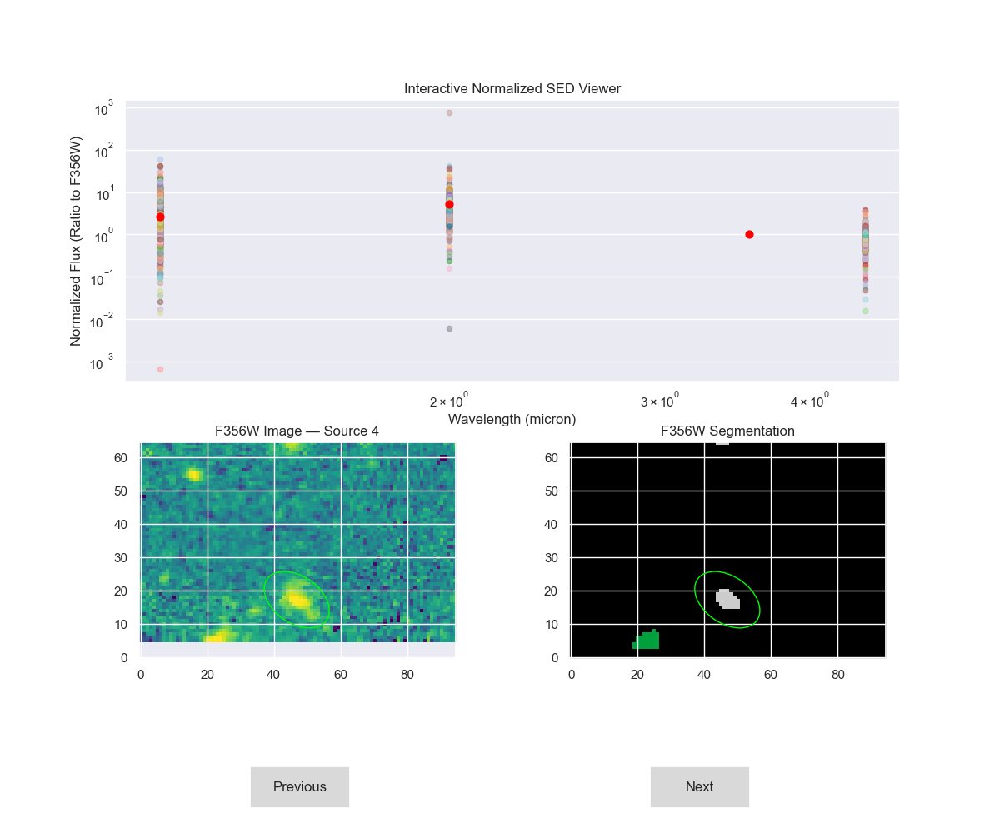

In [190]:
interactive_sed_viewer(
    acc_cat, acc_cat_list, im_subbk_list, wcs_list, segm_deblend,
    flux_115, flux_200, flux_356, flux_444,
    ratio_115, ratio_200, ratio_356, ratio_444
)
